📊 El Análisis Exploratorio de Datos (EDA) es ese paso que a veces se salta por “falta de tiempo”… pero que puede evitar errores costosos.
¿Qué buscamos con un buen EDA?
✅ Ver distribuciones → ¿Hay sesgos? ¿Outliers?
✅ Explorar relaciones entre variables → ¿Correlaciones fuertes? ¿Patrones interesantes?
✅ Detectar errores o valores atípicos
✅ Tomar decisiones: ¿Qué variables usar? ¿Cuál transformar o eliminar?
Herramientas que suelo usar:
🔹 Histogramas y boxplots (para ver forma y valores extremos)
 🔹 Heatmaps de correlación
 🔹 Scatterplots entre variables clave
 🔹 Tablas resumen con describe() o summary()
 🔹 Detección de NA y valores inconsistentes

# Verificación del Directorio

# Importanción de paquetes requeridos

In [ ]:
import statsmodels.api as sm
import scipy.stats as stats
import pylab
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#sns.set()
#importacion de paquetes para el calculo de V de Cramer, Chi**2
from scipy.stats import chi2_contingency, chi2,shapiro,normaltest,anderson
import seaborn as sns
#import statsmodels.api as sm
from statsmodels.formula.api import ols
#from sklearn.impute import SimpleImputer

#from sklearn.model_selection import train_test_split
# from feature-engine

In [ ]:
#Load ENAHO csv file
from google.colab import files
load=files.upload()

Saving data.csv to data.csv


# Lectura de la muestra inicial

In [ ]:
# muestra todas las columns de la bd
pd.set_option('display.max_columns', None)

#lectura muestra inical de deserción del 1C
data = pd. read_csv('data.csv')

#muestra los primeros dos registros de la tabla leida
data.head(20)

,FACTOR,ID_HOGAR,ID_VIVIENDA,nro_Vivienda,HOGAR,LINEA,REGION,ZONA,V1,V2A,V2A1,V2B,V3,V4,V5,V6,V6A,V7A,V7B,V7C,EFI,CalViv,V8,HacDor,V9,HacApo,V10,V11,V12,V13A,V13B,V14A,V14A1,V14B,V15,V16,V17A,V17B1,V17B2,V17B3,V17B4,V17B5,V17B6,SerBa,V18A,V18A1,V18B,V18B1,V18C,V18D,V18E,V18F,V18F1,V18G,V18G1,V18Q,V18Q1,V18H,V18I,V18I1,V18J,V18J1,V18K,V18K1,V18L,V18L1,V18L2,V18M,V18M1,V22,V22A1,V22A2,V22A3,V19,V19B1,V19B2,V19B3,V19B4,V19B8,V19D,V21,V21A,V21B,R4A,R4B,TamHog,TamViv,A3,A4,A5,A6,LugNac,CondMig,RegNac,RegResAnt,A8A,A8B,A9A,A9B,A9C,A10A,A10B,A10C,A11,A12,A13,A14,A15A,A15B,NivInst,Escolari,REZ_ESC,ForReg,A16B,A17,A18A,A18B,A18C,A19A1,A19B1,A19C1,A19A2,A19B2,A19C2,A19A3,A19B3,A19C3,A19A4,A19B4,A19C4,A19A5,A19B5,A19C5,A19A6,A19B6,A19C6,A19A7,A19B7,A19C7,A19A8,A19B8,A19C8,A20A,ForNoReg,A21,A24A,A24B,A24C,A24D,A24E,A22A,A22B,A23,B1,B2,B3,B4,B5,B6,B7A,B7B,B7C,B7D,B7E,B7F,B7G,B7H,B7I,B7J,B7K,B7L,B8,CondAct,OcupPrest,C1,NumEmpl,C2A1,C2A2,C2A3,C2A4,C2B1,C2B2,C2B3,C2B4,HorNorPri,HorNorSec,HorTotNorm,HorEfePri,HorEfeSec,HorTotEfe,C3,C4A,C4B,C5A,C5B,C6A,C6B,SecInsPri,ClasPubPrivPri,C7B,C7C,C7C1,RamaEmpPri,OcupEmpPri,C10,C11,C12,PosiEmpPri,C13A,C13B,C13C,C13D,C13E,C13F,C13F1,C13G,C14,C15,C16A,C16B,C16C,C17,Sub40Hor,SubSinHor,InsLab,Estabili,D1,D2,D3,D4A,D4B,D4C,D7,D8A,D8B1,D8B2,D8B3,D8B4,ContProv,D9,D10,D10A,D11,D12,D13A,D13B,D13C,D13C1,D13D,D13E,D14A,D14B,D14C,D14D,D14E,D14F,D15A,D15A1,D15B,D15B1,D15C,D15C1,D15D,D15E,D15E1,D16,D17,D17A,D19,E1,E2,E3A,E3B,E3C,E4A,E4B,E5A,E5B,FlexiHorLab,E6A,E6B,E6C,E6D,E6E,E6F,E7,E7A,E8A,E8B,E9A,E9B,E9C,E9D,E9E,E10A,E10B,E10C,E11A,E11B,E12A,E12B,E12C,E13A,E13A1,E13B,E13B1,E13C,E13C1,E13D,E13D1,E13E,E13E1,E14A,E14A1,E14A2,E14B,E14B1,E14B2,E14C,E14C1,E14C2,E14D,E14D1,E14D2,E15A,E15B,E15B1,E17,SecInsSec,ClasPubPrivSec,RamaEmpSec,OcupEmpSec,F4,F4A,F5,F6,F7,PosiEmpSec,F8,F8A,F9,F10,F10A,F10B,F10B1,F10C,F10D,F11A,F11A1,F11B,F11B1,F12A,F12B,F12C,F13A,F13B,F13C,F14A,F14B,F15A,F15B,F15B1,G1,G2,G3,G4A,G4B,G4C,G5,G6,SecInsCesa,ClasPubPrivCesa,RamaUltEmpCesant,OcupUltEmpCesant,G10,PosiUltCesa,G11,G12,SecFuerzaTrab,RamaFuerzaTrab,OcupFuerzaTrab,PosiFuerzaTrab,H1A,H1B,H1C,H1D,H1E,H1F,H2A,H2B,H2C,H3A,H3B,H4A,H4B,H5A,H5B,H6A,H6B,H6C,H6D,H6E,H6F,TrabDomNoRem,ActPrimAutCon,OtroActAutCon,ActComVol,ActNoMer,RazNoActEco,H9A,H9A1,H9A2,H9B,H9B1,H9B2,H9C,H9C1,H9C2,H9D,H9D1,H9D2,H9E,H9E1,H9E2,H9P,H9P1,H9P2,H9F,H9F1,H9F2,H9G,H9G1,H9G2,H9Q,H9Q1,H9Q2,H9R,H9R1,H9R2,H9H,H9H1,H9H2,H9S,H9S1,H9S2,H9I,H9I1,H9I2,H9T,H9T1,H9T2,H9K,H9K1,H9K2,H9L,H9L1,H9L2,H9M,H9M1,H9M2,H10A,H10B,H10C,H10C1,spif,aif,gpif,dif,gpina,inmpina,gpsfi,gpia,inmpia,spmb,spmn,ipsp,asp,sesp,bsp,oisp,spnma,spnmv,spnmt,spnmvh,spnmo,ssif,asif,gpsif,dsif,gsi,inmsi,ssmb,ssmn,ssnm,ia,ii,id,ib,trnc,taprnc,ttrnc,timas,ts,tbc,tpa,tapa,tsepa,ttpa,tpn,tapn,ttpn,tpe,tape,ttpe,te,tdp,ot,tnm,ipinm,ipim,ipit,tormsp,tspnm,ipsmb,ipsmn,ipsbt,ipsnt,ipbt,ipnt,isit,issb,issn,isbt,isnt,itrbt,itrnt,irp,ttm,itpb,itpn,sab,san,snab,snan,iag,inag,ipbh,ipnh,isbh,isnh,irph,ttmh,tnmh,itbh,itnh,ithb,ithn,ipcb,ipcn,isanh,iaunh,tsebh,oth,cba,lp,np,IPM_E1,IPM_E2,IPM_E3,IPM_E4,IPM_VUI1,IPM_VUI2,IPM_VUI3,IPM_VUI4,IPM_S1,IPM_S2,IPM_S3,IPM_S4,IPM_T1,IPM_T2.1,IPM_T2.2,IPM_T3,IPM_PS1,IPM_PS2,IPM_PS3,IPM_PS4,IPM_Intensidad,IPM_Pobreza,Q_IPCN,D_IPCN,Q_ZON_IPCN,D_ZON_IPCN,Q_REG_IPCN,D_REG_IPCN,filter_$
0,278,1.0,1.0,11301,1,1,1,1,3,1,NaN,300000.0,1,1,1,1,0,3,3,3,3,4,2,2,4,2,3,1,1,1,1.0,1,1.0,1.0,2,1,1,2,4,5,8,1,4,3,2,NaN,3,1.0,5,7,2,4,NaN,6,NaN,2,NaN,8,1,1.0,3,1.0,6,NaN,7,2.0,0.0,2,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,3.0,0.0,NaN,NaN,1.0,2.0,2,2,1,2,80,5,1,1,1,1,0,0,0,NaN,NaN,0,0,0,8,NaN,0,16,1,NaN,2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,2.0,0.0,2.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
data.shape

(30540, 595)

In [ ]:
#Descripcion de la base de datos
data.info(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30540 entries, 0 to 30539
Data columns (total 595 columns):
 #    Column            Dtype  
---   ------            -----  
 0    FACTOR            int64  
 1    ID_HOGAR          float64
 2    ID_VIVIENDA       float64
 3    nro_Vivienda      int64  
 4    HOGAR             int64  
 5    LINEA             int64  
 6    REGION            int64  
 7    ZONA              int64  
 8    V1                int64  
 9    V2A               int64  
 10   V2A1              float64
 11   V2B               float64
 12   V3                int64  
 13   V4                int64  
 14   V5                int64  
 15   V6                int64  
 16   V6A               int64  
 17   V7A               int64  
 18   V7B               int64  
 19   V7C               int64  
 20   EFI               int64  
 21   CalViv            int64  
 22   V8                int64  
 23   HacDor            int64  
 24   V9                int64  
 25   HacApo            in

In [ ]:
data['V2A'] = data['V2A'].astype('category')

In [ ]:
data['V2A'].value_counts()

,count
V2A,
1,20230
3,5652
2,2233
5,2072
4,353


## Variables con valores únicos

In [ ]:
#Procedimiento para verificar variables con un solo valor o categoría
variables_categoricas = data.select_dtypes(['object']).columns
categorias_unicas = data[variables_categoricas]\
.apply(lambda x: len(x.dropna().unique()))
categorias_unicas

,0


## Creación de función para describir las variables en la muestra

In [ ]:
#creación de función para explorar y describir los datos
def exploracion_de_datos(data):
    """funcion que toma por argumento el DataFrame y genera un objeto de tipo DataFrame con detalles de los datos agregando una columna llamada descripcion
    donde se detallaran cada variable """

    columns = ['Variable','Tipo_variable','Valores_nulos','%_nulos' ,'Ejemplo', 'Definicion' ]
    definicion = ['' for i in range(len(data))]

    # guarda en "variables" la lista de las variables de la base de datos
    variables = data.columns.to_list()

    # Itera sobre cada tipo de variable y guarda los tipos de variables en una lista "variable_type"
    variable_type = [ 'Cualitativa' if col_type == 'object' else 'Numerica' if col_type == 'float64' else 'Categórica' if col_type == 'category' else 'Hora-Fecha' if col_type == 'datetime64[ns]' else 'Numerica' if col_type == 'int64' else 'unknow'for col_type in data.dtypes ]

    # guarda en "null_count" el conteo de nulos para todas las variables
    null_count = data.isnull().sum().to_list()

    # calcula el porcentaje de nulos de cada variable
    porcentaje_de_nulos = round(data.isnull().sum()*100 /len(data),0)
    porcentaje_de_nulos.astype('int32')

    # obtiene un ejemplo no nulo de cada variable para colocarlo en la tabla final
    ejemplar_no_nulo = data[:10000000].dropna(axis=1).iloc[0].to_list()

    # zip todas las listas en "ejemplar" y la convierte en un DataFrame
    ejemplar = zip(variables,variable_type,null_count,porcentaje_de_nulos, ejemplar_no_nulo, definicion)

    # coloca las listas zipeadas y los nombres de las columnas en un DataFrame
    general_data_frame = pd.DataFrame(ejemplar, columns = columns)

    #Exporta to Excel y lo guarda en el directorio que este activo
    #general_data_frame.to_excel('Descripcion_de_datos.xlsx')

    # return
    return general_data_frame

#genera la tabla de descripcion de datos
exploracion_de_datos(data)

,Variable,Tipo_variable,Valores_nulos,%_nulos,Ejemplo,Definicion
0,FACTOR,Numerica,0,0.0,278,
1,ID_HOGAR,Numerica,20161,66.0,11301,
2,ID_VIVIENDA,Numerica,20231,66.0,1,
3,nro_Vivienda,Numerica,0,0.0,1,
4,HOGAR,Numerica,0,0.0,1,
...,...,...,...,...,...,...
72,V22A3,Numerica,11885,39.0,1,
73,V19,Numerica,0,0.0,2,
74,V19B1,Numerica,4775,16.0,6,
75,V19B2,Numerica,4775,16.0,62635,


In [ ]:
lista_eliminar = [var for var in data.columns if data[var].isnull().sum() >= 9162]
len(lista_eliminar)

418

In [ ]:
data2= data.drop(columns=lista_eliminar)

In [ ]:
data2.columns

Index(['FACTOR', 'nro_Vivienda', 'HOGAR', 'LINEA', 'REGION', 'ZONA', 'V1',
       'V2A', 'V2B', 'V3',
       ...
       'IPM_PS2', 'IPM_PS3', 'IPM_PS4', 'IPM_Pobreza', 'Q_IPCN', 'D_IPCN',
       'Q_ZON_IPCN', 'D_ZON_IPCN', 'Q_REG_IPCN', 'D_REG_IPCN'],
      dtype='object', length=177)

In [ ]:
data2

,FACTOR,nro_Vivienda,HOGAR,LINEA,REGION,ZONA,V1,V2A,V2B,V3,V4,V5,V6,V6A,V7A,V7B,V7C,EFI,CalViv,V8,HacDor,V9,HacApo,V10,V11,V12,V13A,V13B,V14A,V14A1,V14B,V15,V16,V17A,V17B1,V17B2,V17B3,V17B4,V17B5,V17B6,SerBa,V18A,V18A1,V18B,V18C,V18D,V18E,V18F,V18G,V18Q,V18H,V18I,V18J,V18K,V18L,V18L1,V18L2,V18M,V22,V19,V19B1,V19B2,V19B3,V19B4,V19B8,V21,R4A,TamHog,TamViv,A3,A4,A5,A6,LugNac,CondMig,RegNac,RegResAnt,A8A,A8B,A9A,A10A,A10B,A10C,A11,A13,A14,A15A,NivInst,Escolari,A20A,A24A,A24B,A24C,A24D,A24E,A22A,B1,CondAct,H1A,H1C,H1E,H2A,H3A,H4A,H5A,H6A,H6B,H6C,H6D,H6E,H6F,TrabDomNoRem,ActPrimAutCon,OtroActAutCon,ActComVol,ActNoMer,H9A,H9B,H9C,H9D,H9E,H9P,H9F,H9G,H9Q,H9R,H9H,H9S,H9I,H9T,H9K,H9L,H9M,ipbh,ipnh,isbh,isnh,irph,ttmh,tnmh,itbh,itnh,ithb,ithn,ipcb,ipcn,isanh,cba,lp,np,IPM_E1,IPM_E2,IPM_E3,IPM_E4,IPM_VUI1,IPM_VUI2,IPM_VUI3,IPM_VUI4,IPM_S1,IPM_S2,IPM_S3,IPM_S4,IPM_T1,IPM_T2.1,IPM_T2.2,IPM_T3,IPM_PS1,IPM_PS2,IPM_PS3,IPM_PS4,IPM_Pobreza,Q_IPCN,D_IPCN,Q_ZON_IPCN,D_ZON_IPCN,Q_REG_IPCN,D_REG_IPCN
0,278,11301,1,1,1,1,3,1,300000.0,1,1,1,1,0,3,3,3,3,4,2,2,4,2,3,1,1,1,1.0,1,1.0,1.0,2,1,1,2,4,5,8,1,4,3,2,NaN,3,5,7,2,4,6,2,8,1,3,6,7,2.0,0.0,2,0,0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,2,2,1,2,80,5,1,1,1,1,0,0,0,0,0,0,8,0,16,1,2,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,975000.0,0.0,0.0,0.0,975000.0,975000.0,487500.0,487500.0,NaN,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,4.0,8.0,4.0,7.0
1,278,11301,1,2,1,1,3,1,300000.0,1,1,1,1,0,3,3,3,3,4,2,2,4,2,3,1,1,1,1.0,1,1.0,1.0,2,1,1,2,4,5,8,1,4,3,2,NaN,3,5,7,2,4,6,2,8,1,3,6,7,2.0,0.0,2,0,0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,2,2,9,2,84,5,1,1,1,1,0,0,0,0,0,0,8,0,16,1,2,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,975000.0,0.0,0.0,0.0,975000.0,975000.0,487500.0,487500.0,NaN,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,4.0,8.0,4.0,7.0
2,278,5933,1,1,1,1,3,1,350000.0,2,1,1,1,0,2,2,2,2,3,3,2,6,2,3,1,1,1,1.0,1,2.0,1.0,2,2,1,2,4,6,8,2,4,3,1,3.0,4,5,8,2,4,6,2,8,2,4,6,7,1.0,1.0,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4,4,1,2,51,2,2,2,7,1,0,0,0,0,0,0,14,0,16,4,2,6,1.0,1.0,0.0,0.0,0.0,5.0,0.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,704167.0,634812.0,0.0,0.0,1040000.0,151667.0,0.0,704167.0,634812.0,1895834.0,1826479.0,473959.0,456620.0,634812.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
3,278,5933,1,2,1,1,3,1,350000.0,2,1,1,1,0,2,2,2,2,3,3,2,6,2,3,1,1,1,1.0,1,2.0,1.0,2,2,1,2,4,6,8,2,4,3,1,3.0,4,5,8,2,4,6,2,8,2,4,6,7,1.0,1.0,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4,4,2,1,61,2,4,2,7,1,1,4,0,0,0,0,8,0,16,4,2,6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,704167.0,634812.0,0.0,0.0,1040000.0,151667.0,0.0,704167.0,634812.0,1895834.0,1826479.0,473959.0,456620.0,634812.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
4,278,5933,1,3,1,1,3,1,350000.0,2,1,1,1,0,2,2,2,2,3,3,2,6,2,3,1,1,1,1.0,1,2.0,1.0,2,2,1,2,4,6,8,2,4,3,1,3.0,4,5,8,2,4,6,2,8,2,4,6,7,1.0,1.0,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4,4,3,2,29,6,0,0,1,1,0,0,0,0,0,0,1,0,52,3,7,13,1.0,1.0,2.0,0.0,0.0,5.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,704167.0,634812.0,0.0,0.0,1040000.0,151667.0,0.0,704167.0,634812.0,1895834.0,1826479.0,473959.0,456620.0,634812.0,62635,129038,3.0,0

In [ ]:
from google.colab import files
load=files.upload()

Saving variables_categoricas.xlsx to variables_categoricas.xlsx


##Load Dictionary ENAHO
This is the information of the variables that used and not used from the original file Original file source: https://sistemas.inec.cr/pad5/index.php/catalog/319

In [ ]:
dictionary = pd.read_excel("variables_categoricas.xlsx")
dictionary


,Nombre,TIPO_REAL,Etiqueta
0,FACTOR,numerica,Factor de expansión
1,nro_Vivienda,numerica,Número de vivienda
2,HOGAR,numerica,Número del hogar
3,LINEA,numerica,Número de línea
4,REGION,Categoría,Región de planificación
...,...,...,...
172,D_IPCN,Categoría,Decil de ingreso per cápita del hogar neto
173,Q_ZON_IPCN,Categoría,Quintil de ingreso per cápita del hogar por zona
174,D_ZON_IPCN,Categoría,Decil de ingreso per cápita del hogar neto por...
175,Q_REG_IPCN,Categoría,Quintil de ingreso per cápita del hogar neto p...


In [ ]:
#lectura muestra inical de deserción del 1C
df_var_cat = pd.read_excel('variables_categoricas.xlsx', sheet_name = 'categoricas')

#muestra los primeros dos registros de la tabla leida
df_var_cat

,Nombre
0,REGION
1,ZONA
2,V1
3,V2A
4,V3
...,...
140,D_IPCN
141,Q_ZON_IPCN
142,D_ZON_IPCN
143,Q_REG_IPCN


In [ ]:
lista_var_categ = list(df_var_cat['Nombre'].values)
lista_var_categ

['REGION',
 'ZONA',
 'V1',
 'V2A',
 'V3',
 'V4',
 'V5',
 'V6',
 'V6A',
 'V7A',
 'V7B',
 'V7C',
 'EFI',
 'CalViv',
 'HacDor',
 'HacApo',
 'V10',
 'V11',
 'V12',
 'V13A',
 'V13B',
 'V14A',
 'V14B',
 'V15',
 'V16',
 'V17A',
 'V17B1',
 'V17B2',
 'V17B3',
 'V17B4',
 'V17B5',
 'V17B6',
 'SerBa',
 'V18A',
 'V18B',
 'V18C',
 'V18D',
 'V18E',
 'V18F',
 'V18G',
 'V18Q',
 'V18H',
 'V18I',
 'V18J',
 'V18K',
 'V18L',
 'V18M',
 'V22',
 'V19',
 'V19B1',
 'V19B2',
 'V19B3',
 'V19B4',
 'V19B8',
 'V21',
 'R4A',
 'A3',
 'A4',
 'A5',
 'A6',
 'LugNac',
 'CondMig',
 'RegNac',
 'RegResAnt',
 'A8A',
 'A8B',
 'A9A',
 'A10A',
 'A10B',
 'A10C',
 'A11',
 'A13',
 'A14',
 'A15A',
 'NivInst',
 'Escolari',
 'A20A',
 'A24B',
 'A24C',
 'A24D',
 'A24E',
 'A22A',
 'B1',
 'CondAct',
 'H1A',
 'H1C',
 'H1E',
 'H2A',
 'H3A',
 'H4A',
 'H5A',
 'H6A',
 'H6B',
 'H6C',
 'H6D',
 'H6E',
 'H6F',
 'TrabDomNoRem',
 'ActPrimAutCon',
 'OtroActAutCon',
 'ActComVol',
 'ActNoMer',
 'H9A',
 'H9B',
 'H9C',
 'H9E',
 'H9P',
 'H9F',
 'H9G',
 'H

In [ ]:
data2[lista_var_categ]

,REGION,ZONA,V1,V2A,V3,V4,V5,V6,V6A,V7A,V7B,V7C,EFI,CalViv,HacDor,HacApo,V10,V11,V12,V13A,V13B,V14A,V14B,V15,V16,V17A,V17B1,V17B2,V17B3,V17B4,V17B5,V17B6,SerBa,V18A,V18B,V18C,V18D,V18E,V18F,V18G,V18Q,V18H,V18I,V18J,V18K,V18L,V18M,V22,V19,V19B1,V19B2,V19B3,V19B4,V19B8,V21,R4A,A3,A4,A5,A6,LugNac,CondMig,RegNac,RegResAnt,A8A,A8B,A9A,A10A,A10B,A10C,A11,A13,A14,A15A,NivInst,Escolari,A20A,A24B,A24C,A24D,A24E,A22A,B1,CondAct,H1A,H1C,H1E,H2A,H3A,H4A,H5A,H6A,H6B,H6C,H6D,H6E,H6F,TrabDomNoRem,ActPrimAutCon,OtroActAutCon,ActComVol,ActNoMer,H9A,H9B,H9C,H9E,H9P,H9F,H9G,H9R,H9S,H9T,H9K,H9L,H9M,cba,lp,np,IPM_E1,IPM_E2,IPM_E3,IPM_E4,IPM_VUI1,IPM_VUI2,IPM_VUI3,IPM_VUI4,IPM_S1,IPM_S2,IPM_S3,IPM_S4,IPM_T1,IPM_T2.1,IPM_T2.2,IPM_T3,IPM_PS1,IPM_PS2,IPM_PS3,IPM_PS4,IPM_Pobreza,Q_IPCN,D_IPCN,Q_ZON_IPCN,D_ZON_IPCN,Q_REG_IPCN,D_REG_IPCN
0,1,1,3,1,1,1,1,1,0,3,3,3,3,4,2,2,3,1,1,1,1.0,1,1.0,2,1,1,2,4,5,8,1,4,3,2,3,5,7,2,4,6,2,8,1,3,6,7,2,0,0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,2,80,5,1,1,1,1,0,0,0,0,0,0,8,0,16,1,2,6,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,4.0,8.0,4.0,7.0
1,1,1,3,1,1,1,1,1,0,3,3,3,3,4,2,2,3,1,1,1,1.0,1,1.0,2,1,1,2,4,5,8,1,4,3,2,3,5,7,2,4,6,2,8,1,3,6,7,2,0,0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,9,2,84,5,1,1,1,1,0,0,0,0,0,0,8,0,16,1,2,6,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,4.0,8.0,4.0,7.0
2,1,1,3,1,2,1,1,1,0,2,2,2,2,3,2,2,3,1,1,1,1.0,1,1.0,2,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,2,51,2,2,2,7,1,0,0,0,0,0,0,14,0,16,4,2,6,1.0,0.0,0.0,0.0,5.0,0.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
3,1,1,3,1,2,1,1,1,0,2,2,2,2,3,2,2,3,1,1,1,1.0,1,1.0,2,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2,1,61,2,4,2,7,1,1,4,0,0,0,0,8,0,16,4,2,6,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
4,1,1,3,1,2,1,1,1,0,2,2,2,2,3,2,2,3,1,1,1,1.0,1,1.0,2,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,2,29,6,0,0,1,1,0,0,0,0,0,0,1,0,52,3,7,13,1.0,2.0,0.0,0.0,5.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30535,5,2,3,3,1,1,1,1,0,3,3,3,3,4,2,2,4,1,2,2,1.0,1,1.0,1,2,3,1,3,5,7,1,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,2,1,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,3,1,6,0,0,0,5,5,0,0,0,0,0,0,5,2,0,1,0,0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
# Convertir todas las columnas de tipo 'object' a tipo 'category'
data2[lista_var_categ] = data2[lista_var_categ].apply(lambda x: x.astype('category'))

#  Verifica los tipos de datos
data2.info(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30540 entries, 0 to 30539
Data columns (total 177 columns):
 #    Column         Dtype   
---   ------         -----   
 0    FACTOR         int64   
 1    nro_Vivienda   int64   
 2    HOGAR          int64   
 3    LINEA          int64   
 4    REGION         category
 5    ZONA           category
 6    V1             category
 7    V2A            category
 8    V2B            float64 
 9    V3             category
 10   V4             category
 11   V5             category
 12   V6             category
 13   V6A            category
 14   V7A            category
 15   V7B            category
 16   V7C            category
 17   EFI            category
 18   CalViv         category
 19   V8             int64   
 20   HacDor         category
 21   V9             int64   
 22   HacApo         category
 23   V10            category
 24   V11            category
 25   V12            category
 26   V13A           category
 27   V13B          

##Creación de función para describir las variables en la muestra

In [ ]:
#creación de función para explorar y describir los datos
def exploracion_de_datos(data2):
    """funcion que toma por argumento el DataFrame y genera un objeto de tipo DataFrame con detalles de los datos agregando una columna llamada descripcion
    donde se detallaran cada variable """

    columns = ['Variable','Tipo_variable','Valores_nulos','%_nulos' ,'Ejemplo', 'Definicion' ]
    definicion = ['' for i in range(len(data2))]

    # guarda en "variables" la lista de las variables de la base de datos
    variables = data2.columns.to_list()

    # Itera sobre cada tipo de variable y guarda los tipos de variables en una lista "variable_type"
    variable_type = [ 'Cualitativa' if col_type == 'object' else 'Numerica' if col_type == 'float64' else 'Categórica' if col_type == 'category' else 'Hora-Fecha' if col_type == 'datetime64[ns]' else 'Numerica' if col_type == 'int64' else 'unknow'for col_type in data2.dtypes ]

    # guarda en "null_count" el conteo de nulos para todas las variables
    null_count = data2.isnull().sum().to_list()

    # calcula el porcentaje de nulos de cada variable
    porcentaje_de_nulos = round(data2.isnull().sum()*100 /len(data2),0)
    porcentaje_de_nulos.astype('int32')

    # obtiene un ejemplo no nulo de cada variable para colocarlo en la tabla final
    ejemplar_no_nulo = data2[:10000000].dropna(axis=1).iloc[0].to_list()

    # zip todas las listas en "ejemplar" y la convierte en un DataFrame
    ejemplar = zip(variables,variable_type,null_count,porcentaje_de_nulos, ejemplar_no_nulo, definicion)

    # coloca las listas zipeadas y los nombres de las columnas en un DataFrame
    general_data_frame = pd.DataFrame(ejemplar, columns = columns)

    #Exporta to Excel y lo guarda en el directorio que este activo
    #general_data_frame.to_excel('Descripcion_de_datos.xlsx')

    # return
    return general_data_frame

#genera la tabla de descripcion de datos
exploracion_de_datos(data)

,Variable,Tipo_variable,Valores_nulos,%_nulos,Ejemplo,Definicion
0,FACTOR,Numerica,0,0.0,278,
1,ID_HOGAR,Numerica,20161,66.0,11301,
2,ID_VIVIENDA,Numerica,20231,66.0,1,
3,nro_Vivienda,Numerica,0,0.0,1,
4,HOGAR,Numerica,0,0.0,1,
...,...,...,...,...,...,...
72,V22A3,Numerica,11885,39.0,1,
73,V19,Numerica,0,0.0,2,
74,V19B1,Numerica,4775,16.0,6,
75,V19B2,Numerica,4775,16.0,62635,


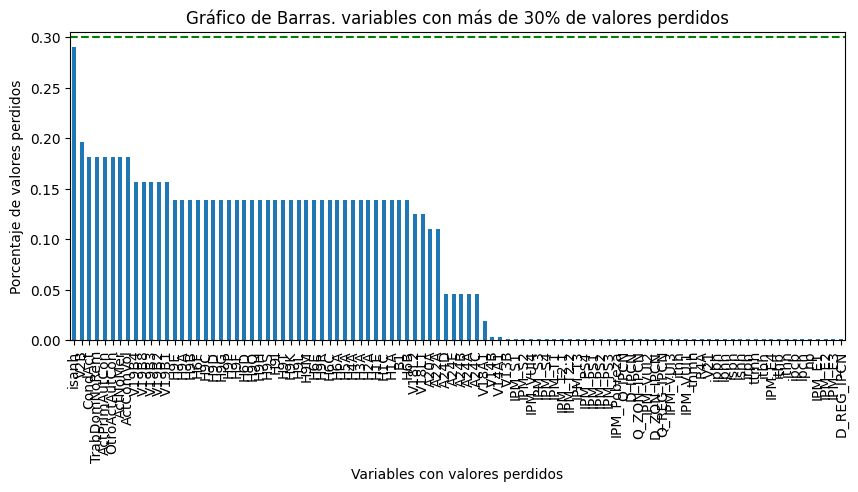

In [ ]:
#crea lista de variables con valores perdidos
vars_con_na = [var for var in data2.columns if data2[var].isnull().sum() >0]

# determina el porcentaje de valores perdidos (en decimales)
# muestra los resultados de forma ordenada
data2[vars_con_na].isnull().mean().sort_values(ascending=False)

#gráfico de variables con más de 30% de valores perdidos
data2[vars_con_na].isnull().mean().sort_values(ascending=False).plot.bar(figsize=(10, 4))
plt.title("Gráfico de Barras. variables con más de 30% de valores perdidos")
plt.ylabel('Porcentaje de valores perdidos')
plt.axhline(y=0.30, color='g', linestyle='--')
plt.xlabel("Variables con valores perdidos")
#rota la inclinación de las categorias en el eje x
plt.xticks(rotation=90)
plt.show()

## Análisis de la variable "etiqueta" (variable objetivo:IPM Vivienda y uso de internet 3: Hacinamiento IPM_VUI3)

In [ ]:
#genera conteo de la variable "etiqueta"
data['IPM_VUI3'].value_counts()

,count
IPM_VUI3,
0.0,27820
1.0,2694


In [ ]:
#genera las proporciones de las categorias de la variable "etiqueta"
data['IPM_VUI3'].value_counts(normalize=True)

,proportion
IPM_VUI3,
0.0,0.911713
1.0,0.088287


# Gráfico de barras de "etiqueta"

In [ ]:
#!pip install plotly

In [ ]:
import plotly.graph_objects as go
temp = dict(layout=go.Layout(font=dict(family="Franklin Gothic", size=12),height=500, width=1000))

target = data['IPM_VUI3'].value_counts(normalize=True)
target.rename(index={1:'Con la privación',0:'Sin la privación'},inplace=True)
pal, color = ['#016CC9','#DEB078'], ['#8DBAE2','#EDD3B3']
fig = go.Figure()
fig.add_trace(go.Pie(labels=target.index, values=target*100, hole=.45,
                    showlegend=True,sort=False,
                    marker=dict(colors=color,line=dict(color=pal,width=2.5)),
                    hovertemplate = "%{label} Accounts: %{value:.2f}%<extra></extra>"))

fig.update_layout(template=temp, title='Distribución de la variable "Hacinamiento"',
                  legend=dict(traceorder='reversed',y=1.05,x=0),
                  uniformtext_minsize=15, uniformtext_mode='hide',width=700)
fig.show()

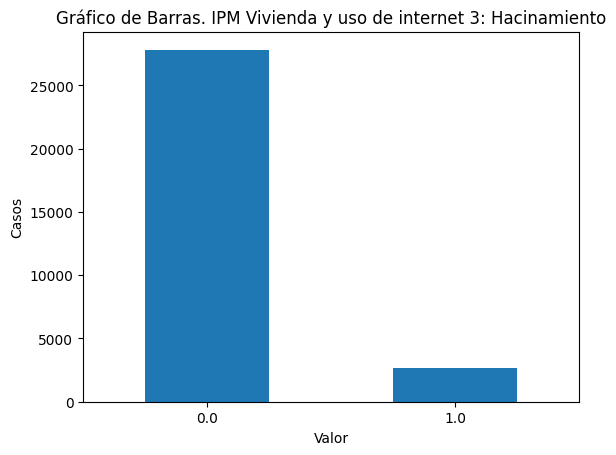

In [ ]:
#grafico de barras (frecuencias) de la variable "etiqueta"

#genera el grafico de barras de valores absolutos
data['IPM_VUI3'].value_counts(normalize = False).plot.bar()

#título
plt.title("Gráfico de Barras. IPM Vivienda y uso de internet 3: Hacinamiento")

#título de x
plt.xlabel("Valor")

#título de y
plt.ylabel("Casos")

#rota la inclinación de las categorias en el eje x
plt.xticks(rotation=360)

#muestra el gráfico
plt.show()

## Análisis de valores perdidos (Missing Values)

In [ ]:
#genera un listado de variables donde "True" significa que la variable tiene menos de 20% de valores perdidos
ind_keep = data2.isna().sum()/data.shape[0] < 0.20

#se imprime el listado de variables
print(ind_keep)

FACTOR          True
nro_Vivienda    True
HOGAR           True
LINEA           True
REGION          True
                ... 
D_IPCN          True
Q_ZON_IPCN      True
D_ZON_IPCN      True
Q_REG_IPCN      True
D_REG_IPCN      True
Length: 177, dtype: bool


In [ ]:
#crea lista de variables con valores perdidos
vars_con_na = [var for var in data2.columns if data2[var].isnull().sum() > 0]

# determina el porcentaje de valores perdidos (en decimales)
# muestra los resultados de forma ordenada
data2[vars_con_na].isnull().mean().sort_values(ascending=False)

,0
isanh,0.290439
V2B,0.196627
CondAct,0.181336
TrabDomNoRem,0.181336
ActPrimAutCon,0.181336
...,...
np,0.000851
IPM_E1,0.000851
IPM_E2,0.000851
IPM_E3,0.000851


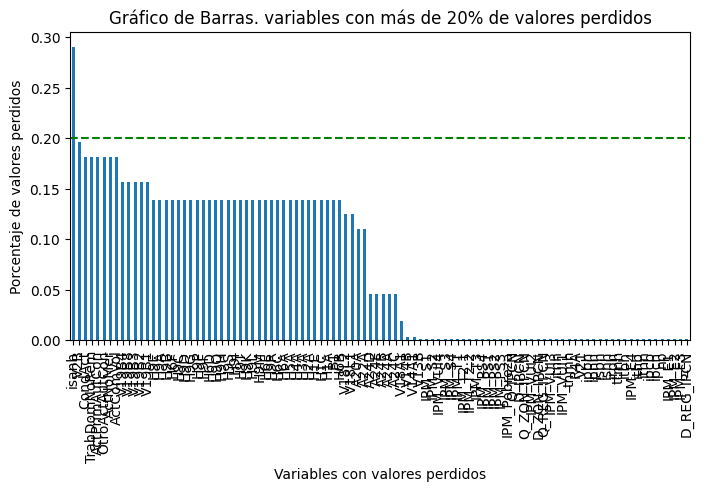

In [ ]:
#gráfico de variables con más de 20% de valores perdidos
data2[vars_con_na].isnull().mean().sort_values(ascending=False).plot.bar(figsize=(8, 4))
plt.title("Gráfico de Barras. variables con más de 20% de valores perdidos")
plt.ylabel('Porcentaje de valores perdidos')
plt.axhline(y=0.20, color='g', linestyle='--')
plt.xlabel("Variables con valores perdidos")
#rota la inclinación de las categorias en el eje x
plt.xticks(rotation=90)
plt.show()

## Separación de las variables "numéricas" y "categóricas"

In [ ]:
#crea una lista de categóricas
var_cat = [var for var in data2.columns if data2[var].dtype == 'category']

#imprime la lista de categóricas
print(var_cat)

['REGION', 'ZONA', 'V1', 'V2A', 'V3', 'V4', 'V5', 'V6', 'V6A', 'V7A', 'V7B', 'V7C', 'EFI', 'CalViv', 'HacDor', 'HacApo', 'V10', 'V11', 'V12', 'V13A', 'V13B', 'V14A', 'V14B', 'V15', 'V16', 'V17A', 'V17B1', 'V17B2', 'V17B3', 'V17B4', 'V17B5', 'V17B6', 'SerBa', 'V18A', 'V18B', 'V18C', 'V18D', 'V18E', 'V18F', 'V18G', 'V18Q', 'V18H', 'V18I', 'V18J', 'V18K', 'V18L', 'V18M', 'V22', 'V19', 'V19B1', 'V19B2', 'V19B3', 'V19B4', 'V19B8', 'V21', 'R4A', 'A3', 'A4', 'A5', 'A6', 'LugNac', 'CondMig', 'RegNac', 'RegResAnt', 'A8A', 'A8B', 'A9A', 'A10A', 'A10B', 'A10C', 'A11', 'A13', 'A14', 'A15A', 'NivInst', 'Escolari', 'A20A', 'A24B', 'A24C', 'A24D', 'A24E', 'A22A', 'B1', 'CondAct', 'H1A', 'H1C', 'H1E', 'H2A', 'H3A', 'H4A', 'H5A', 'H6A', 'H6B', 'H6C', 'H6D', 'H6E', 'H6F', 'TrabDomNoRem', 'ActPrimAutCon', 'OtroActAutCon', 'ActComVol', 'ActNoMer', 'H9A', 'H9B', 'H9C', 'H9E', 'H9P', 'H9F', 'H9G', 'H9R', 'H9S', 'H9T', 'H9K', 'H9L', 'H9M', 'cba', 'lp', 'np', 'IPM_E1', 'IPM_E2', 'IPM_E3', 'IPM_E4', 'IPM_VUI1'

In [ ]:
#crea una lista de numéricas
var_num = [var for var in data2.columns if var not in var_cat ]

#imprime las numéricas
print(var_num)

['FACTOR', 'nro_Vivienda', 'HOGAR', 'LINEA', 'V2B', 'V8', 'V9', 'V14A1', 'V18A1', 'V18L1', 'V18L2', 'TamHog', 'TamViv', 'A24A', 'H9D', 'H9Q', 'H9H', 'H9I', 'ipbh', 'ipnh', 'isbh', 'isnh', 'irph', 'ttmh', 'tnmh', 'itbh', 'itnh', 'ithb', 'ithn', 'ipcb', 'ipcn', 'isanh']


## Análisis exploratorio de las variables numéricas

In [ ]:
#imprime la cantidad numéricas en la muestra
print('Número de variables numéricas: ', len(var_num))

# visualiza las numéricas
data2[var_num].head()

Número de variables numéricas:  32


,FACTOR,nro_Vivienda,HOGAR,LINEA,V2B,V8,V9,V14A1,V18A1,V18L1,V18L2,TamHog,TamViv,A24A,H9D,H9Q,H9H,H9I,ipbh,ipnh,isbh,isnh,irph,ttmh,tnmh,itbh,itnh,ithb,ithn,ipcb,ipcn,isanh
0,278,11301,1,1,300000.0,2,4,1.0,NaN,2.0,0.0,2,2,0.0,2.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,975000.0,0.0,0.0,0.0,975000.0,975000.0,487500.0,487500.0,NaN
1,278,11301,1,2,300000.0,2,4,1.0,NaN,2.0,0.0,2,2,0.0,2.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,975000.0,0.0,0.0,0.0,975000.0,975000.0,487500.0,487500.0,NaN
2,278,5933,1,1,350000.0,3,6,2.0,3.0,1.0,1.0,4,4,1.0,2.0,2.0,2.0,2.0,704167.0,634812.0,0.0,0.0,1040000.0,151667.0,0.0,704167.0,634812.0,1895834.0,1826479.0,473959.0,456620.0,634812.0
3,278,5933,1,2,350000.0,3,6,2.0,3.0,1.0,1.0,4,4,0.0,2.0,2.0,1.0,2.0,704167.0,634812.0,0.0,0.0,1040000.0,151667.0,0.0,704167.0,634812.0,1895834.0,1826479.0,473959.0,456620.0,634812.0
4,278,5933,1,3,350000.0,3,6,2.0,3.0,1.0,1.0,4,4,1.0,2.0,2.0,2.0,2.0,704167.0,634812.0,0.0,0.0,1040000.0,151667.0,0.0,704167.0,634812.0,1895834.0,1826479.0,473959.0,456620.0,634812.0


## Estadisticas descriptivas de las numéricas

In [ ]:
#establece el formato de los numeros a 3 decimales
pd.set_option('float_format', '{:.1f}'.format)

#genera tabla resumen de las variables numéricas
data2[var_num].describe()

,FACTOR,nro_Vivienda,HOGAR,LINEA,V2B,V8,V9,V14A1,V18A1,V18L1,V18L2,TamHog,TamViv,A24A,H9D,H9Q,H9H,H9I,ipbh,ipnh,isbh,isnh,irph,ttmh,tnmh,itbh,itnh,ithb,ithn,ipcb,ipcn,isanh
count,30540.0,30540.0,30540.0,30540.0,24535.0,30540.0,30540.0,30445.0,29944.0,26715.0,26715.0,30540.0,30540.0,29126.0,26303.0,26303.0,26303.0,26303.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,21670.0
mean,172.3,6686.6,1.0,2.4,2171153.4,2.7,4.8,1.3,2.8,1.7,1.1,3.8,3.8,0.9,2.0,2.0,1.9,2.0,1001190.4,920749.7,10566.0,10381.5,39455.9,148995.2,2969.2,1011756.4,931131.2,1203176.7,1122551.4,368238.8,344019.3,1068646.9
std,52.1,3873.6,0.1,1.4,13966683.9,0.9,1.4,0.6,1.3,1.0,1.0,3.2,1.7,0.3,0.1,0.2,0.3,0.0,1273676.9,1157981.9,114841.2,113067.2,274342.5,325230.2,23680.3,1297394.1,1180898.2,1374350.5,1264176.5,472111.2,434723.9,997481.1
min,38.0,1.0,1.0,1.0,10000.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9750.0
25%,144.0,3295.0,1.0,1.0,80000.0,2.0,4.0,1.0,2.0,1.0,0.0,3.0,3.0,1.0,2.0,2.0,2.0,2.0,260000.0,260000.0,0.0,0.0,0.0,0.0,0.0,260000.0,260000.0,418000.0,404333.0,119493.5,116000.0,455000.0
50%,162.0,6700.0,1.0,2.0,150000.0,3.0,5.0,1.0,3.0,1.0,1.0,4.0,4.0,1.0,2.0,2.0,2.0,2.0,633750.0,589333.0,0.0,0.0,0.0,25000.0,0.0,641600.0,594837.0,783667.0,744996.0,227500.0,216524.0,761784.0
75%,187.0,10036.0,1.0,3.0,250000.0,3.0,6.0,1.0,4.0,2.0,2.0,5.0,5.0,1.0,2.0,2.0,2.0,2.0,1300000.0,1206142.0,0.0,0.0,0.0,168000.0,0.0,1308766.2,1217813.0,1484708.0,1380785.5,440758.0,412712.0,1318161.0
max,1414.0,13437.0,5.0,17.0,99999999.0,9.0,13.0,7.0,12.0,8.0,8.0,99.0,17.0,1.0,2.0,2.0,2.0,2.0,28578334.0,28223122.0,3900000.0,3900000.0,8736000.0,7150000.0,800000.0,28578334.0,28223122.0,28578334.0,28223122.0,9977500.0,9543712.0,17419350.0


## Histogramas de numéricas

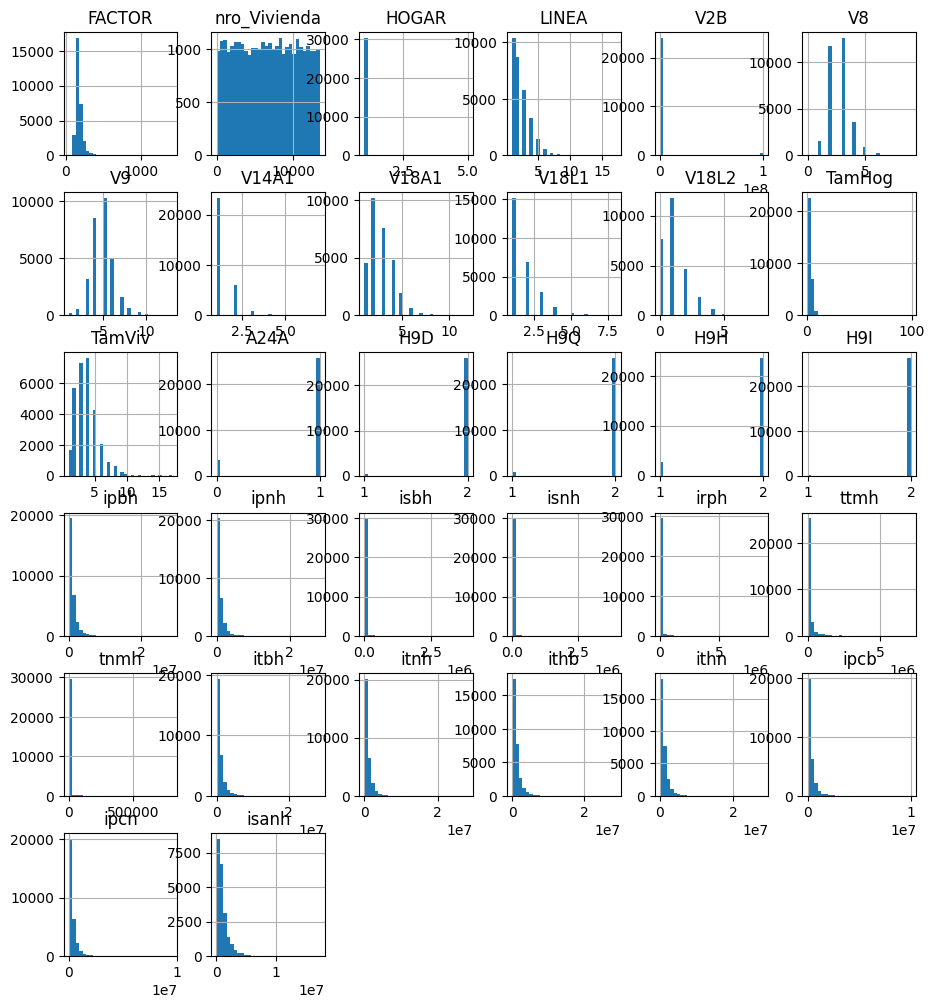

In [ ]:
# genera Histogramas
data2[var_num].hist(bins=30, figsize=(11,12))
plt.show()

## Análisis de normalidad

FACTOR


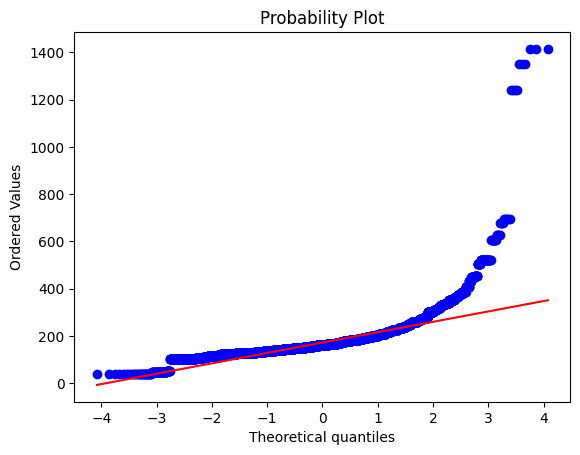

nro_Vivienda


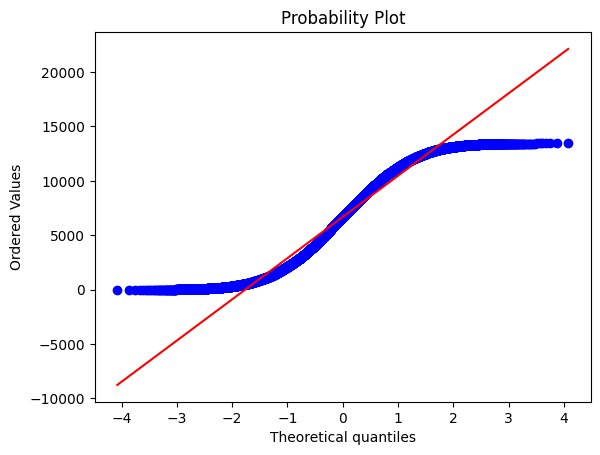

HOGAR


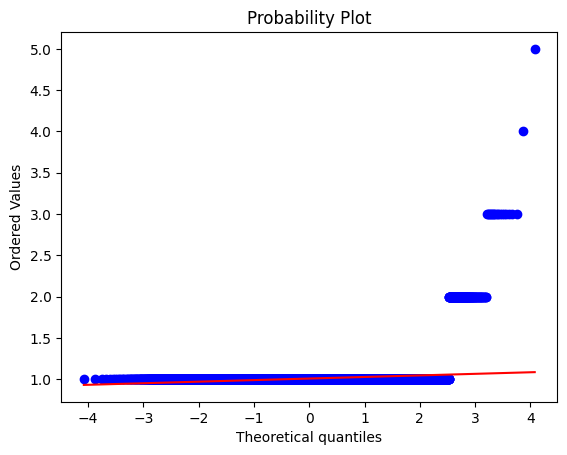

LINEA


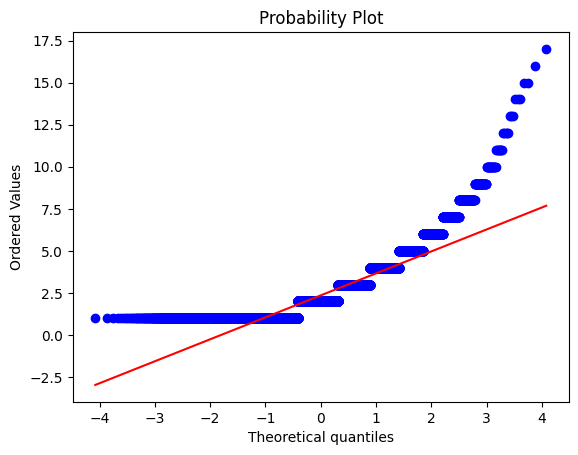

V2B


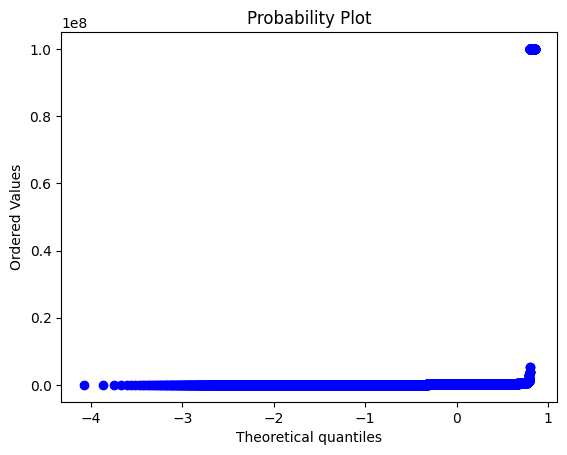

V8


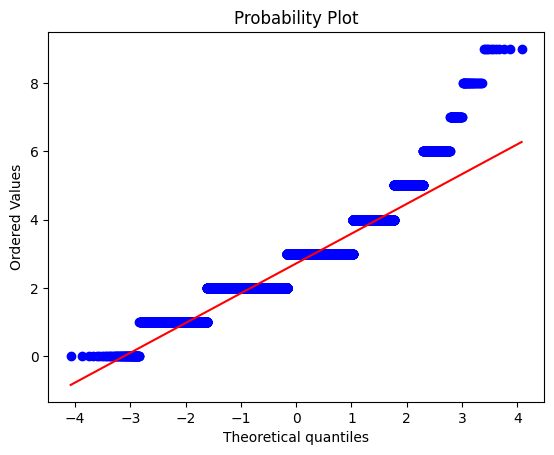

V9


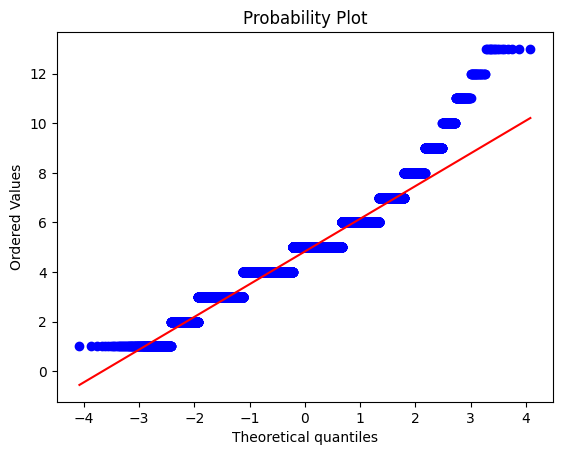

V14A1


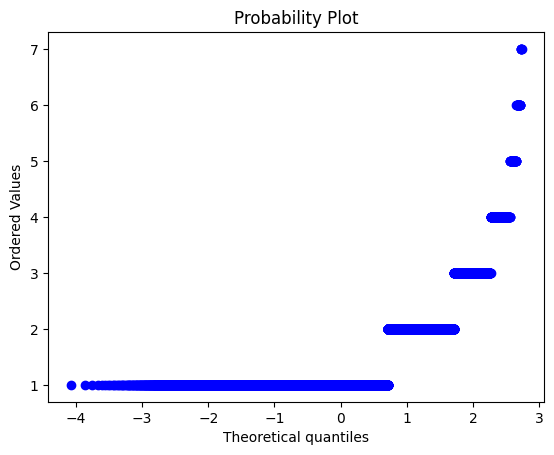

V18A1


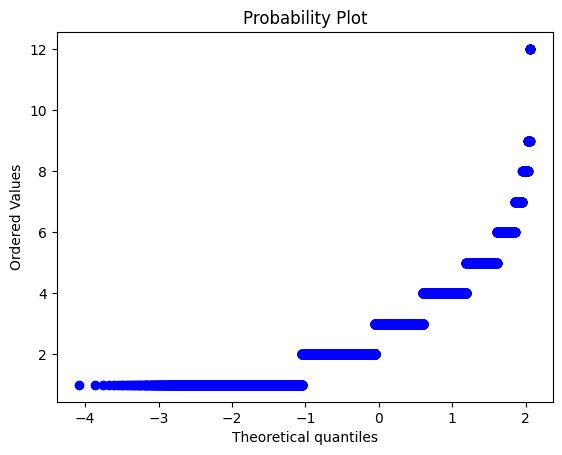

V18L1


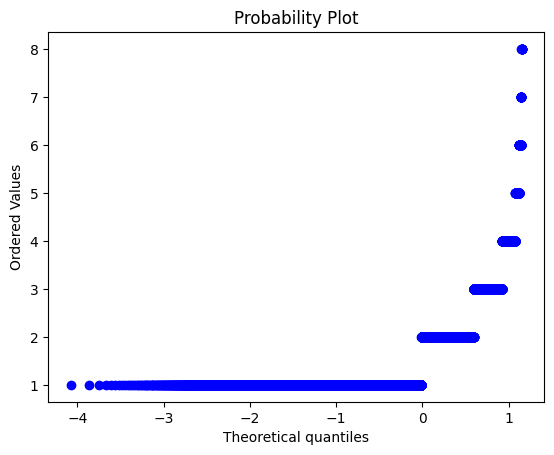

V18L2


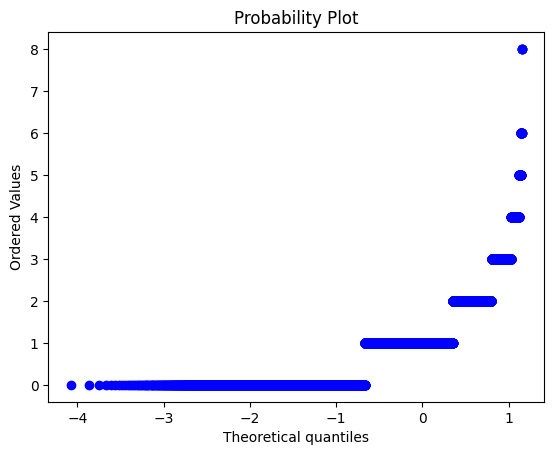

TamHog


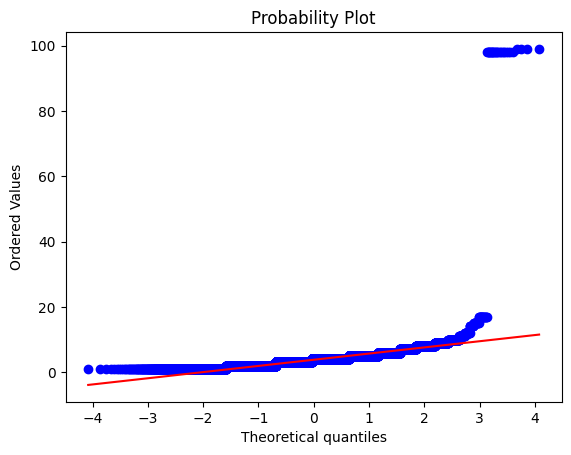

TamViv


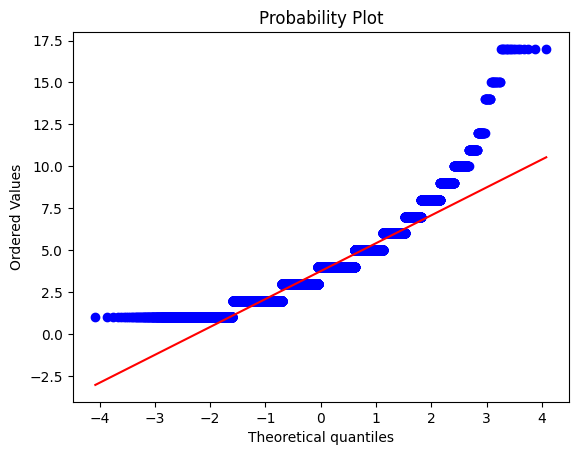

A24A


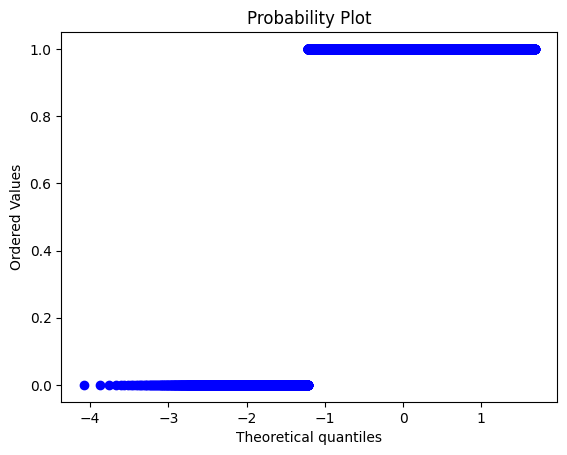

H9D


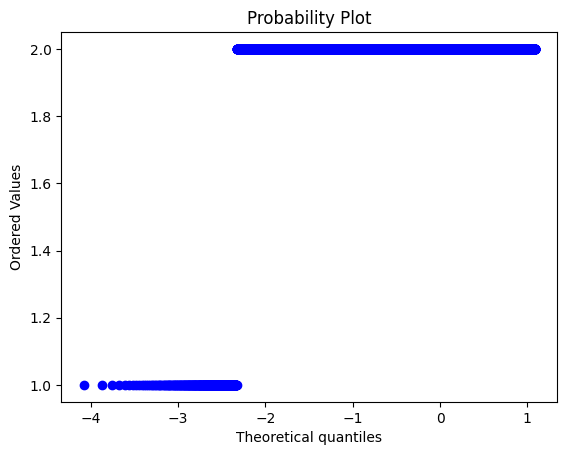

H9Q


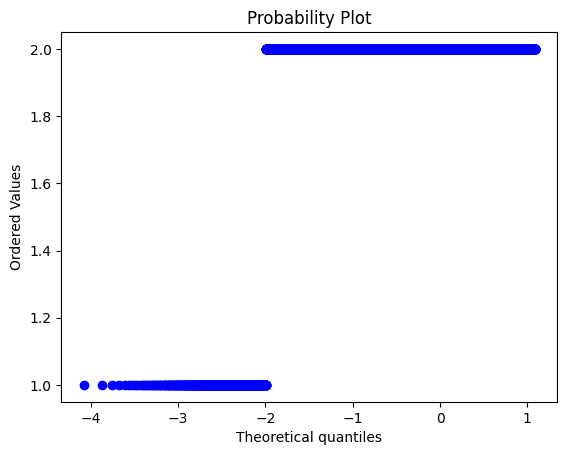

H9H


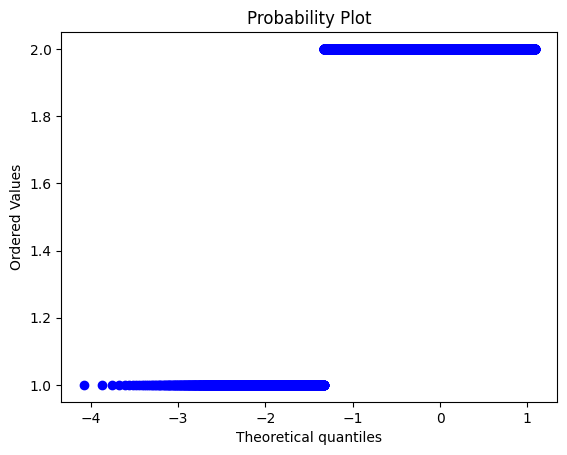

H9I


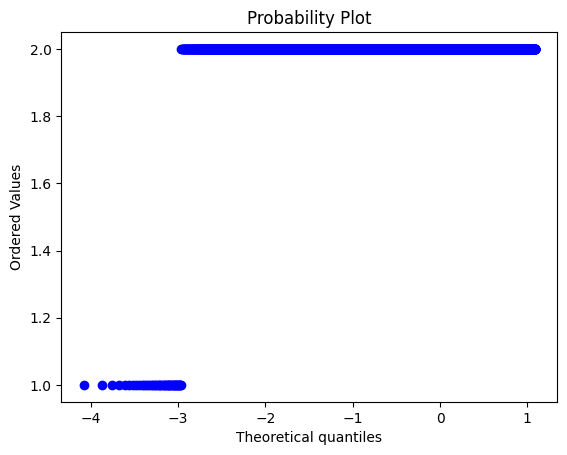

ipbh


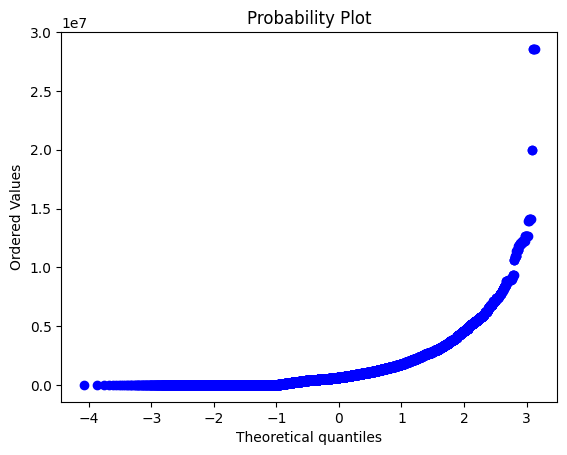

ipnh


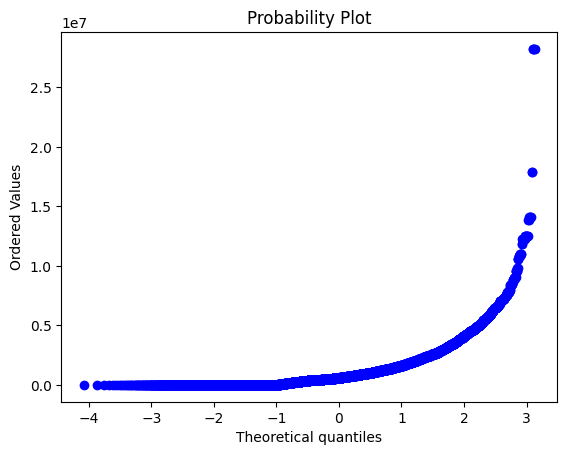

isbh


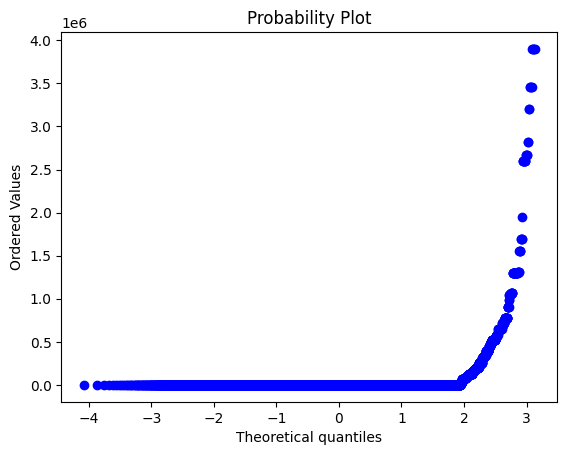

isnh


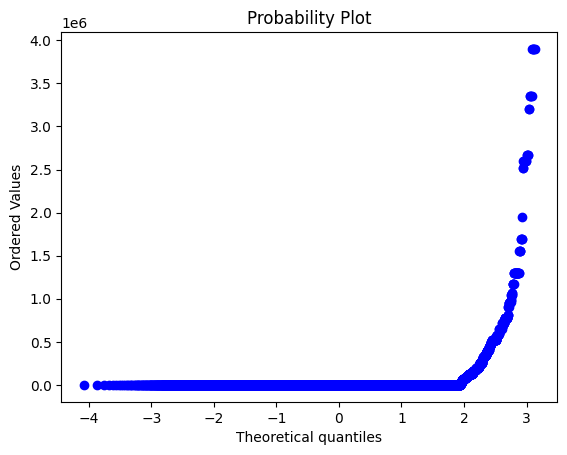

irph


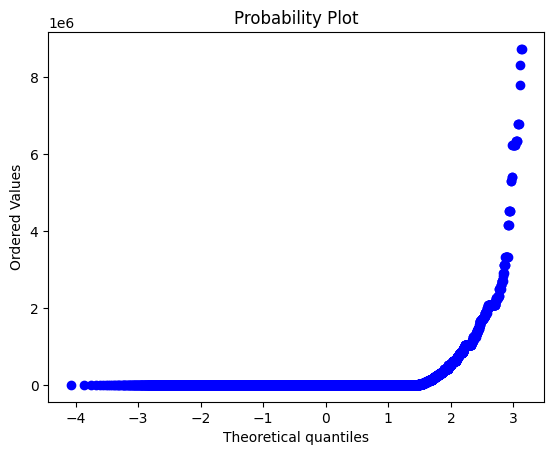

ttmh


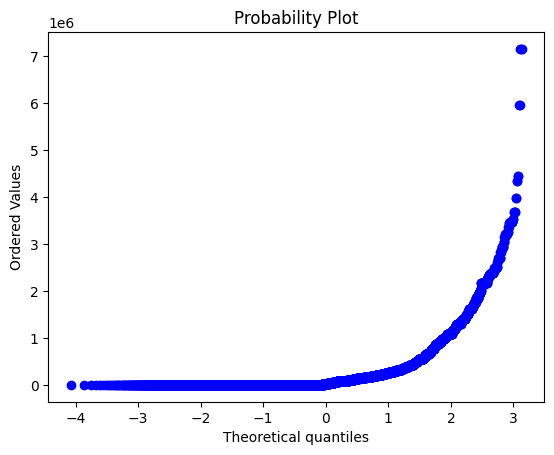

tnmh


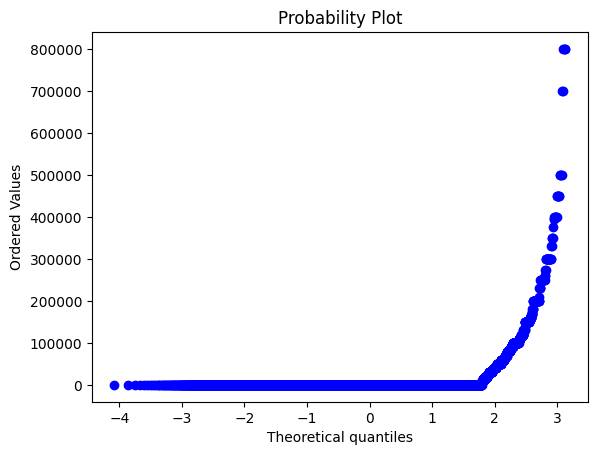

itbh


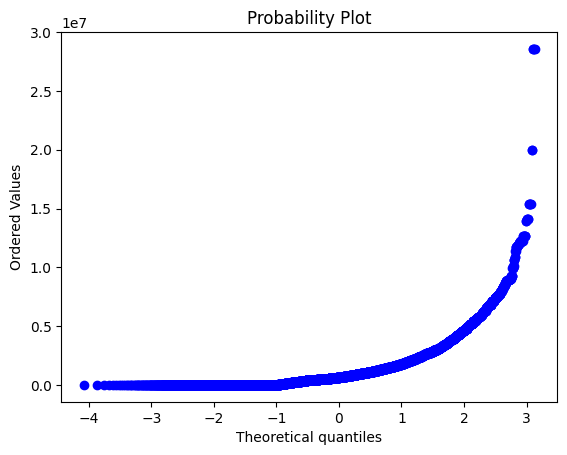

itnh


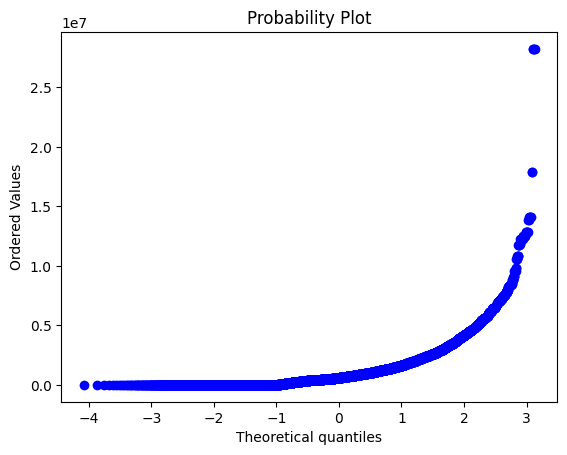

ithb


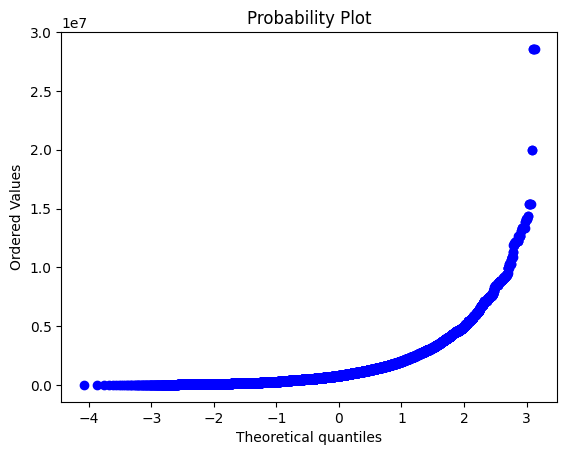

ithn


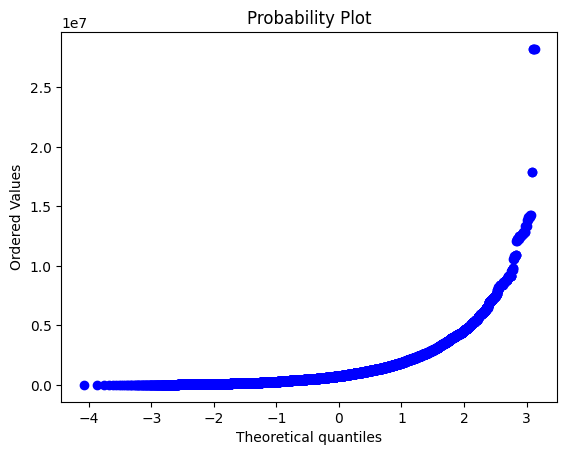

ipcb


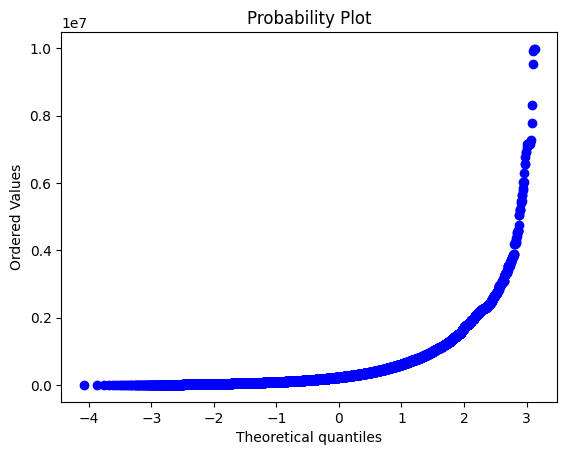

ipcn


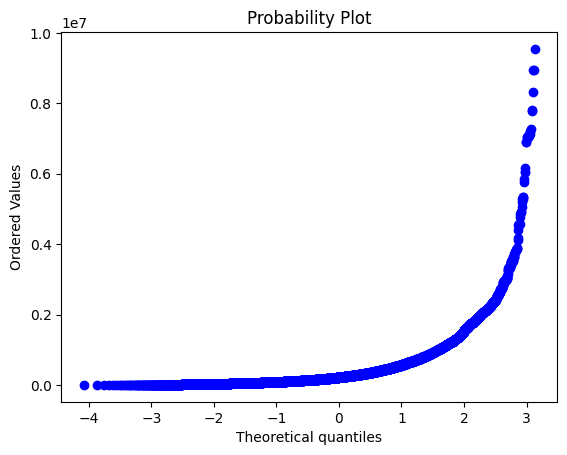

isanh


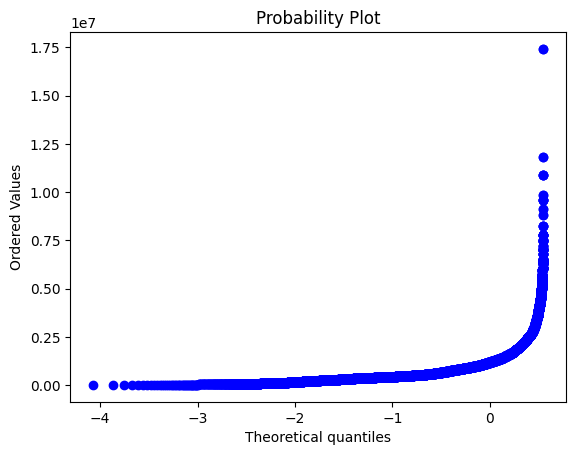

In [ ]:
for i in data2[var_num].columns:
    measurements = np.random.normal(loc = 20,scale = 5,size=150)
    print(i)
    stats.probplot(data2[i], dist="norm",plot=pylab)
    pylab.show()

## Graficos de Cajas

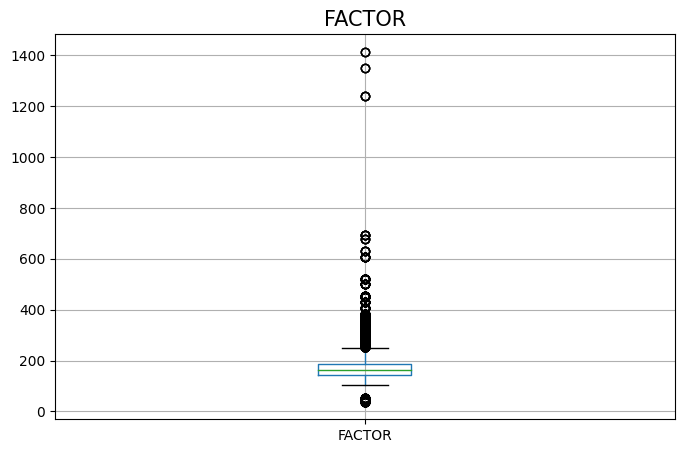

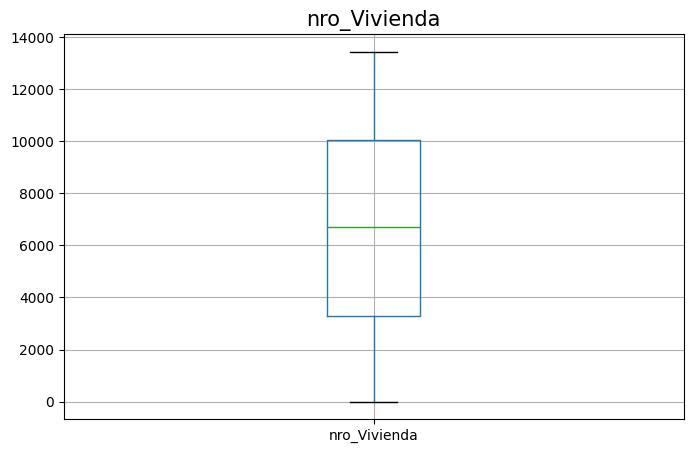

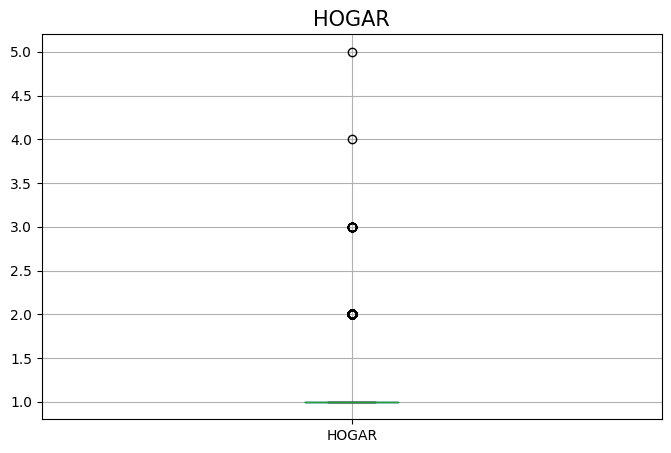

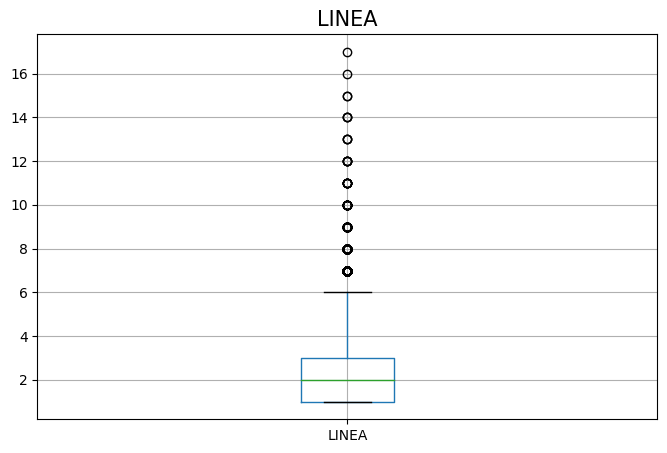

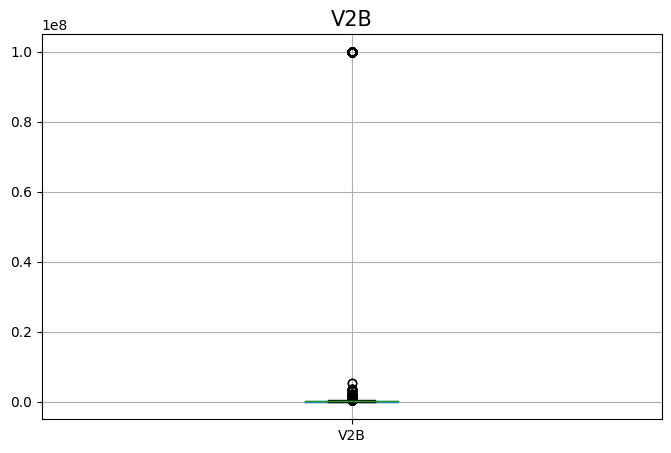

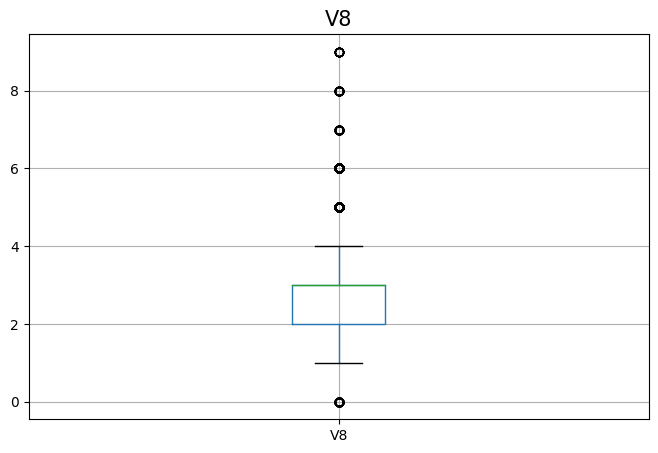

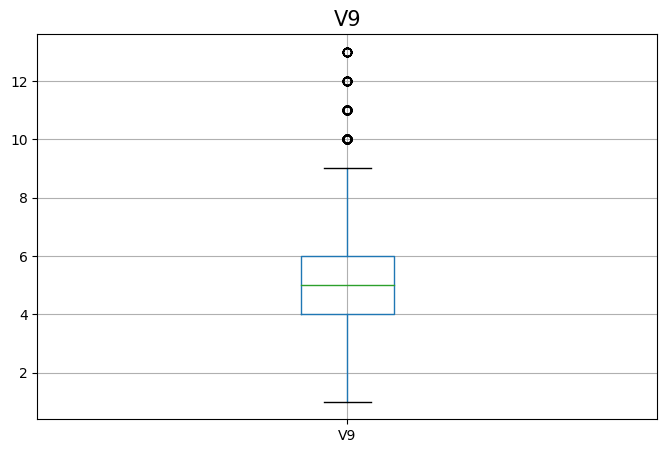

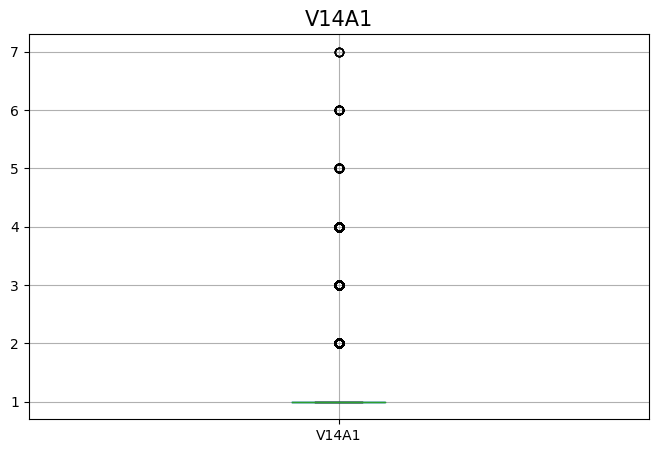

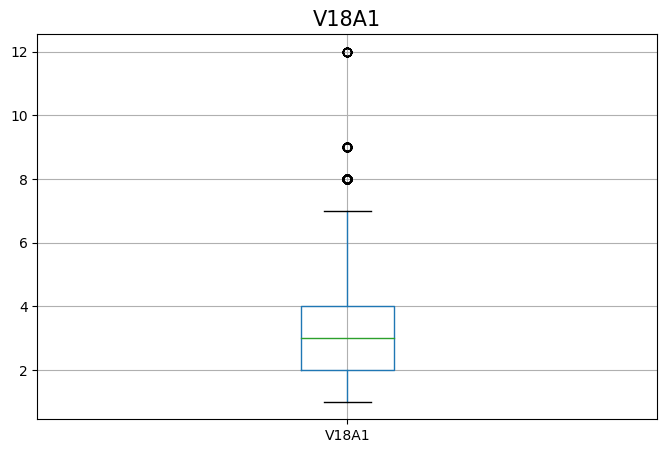

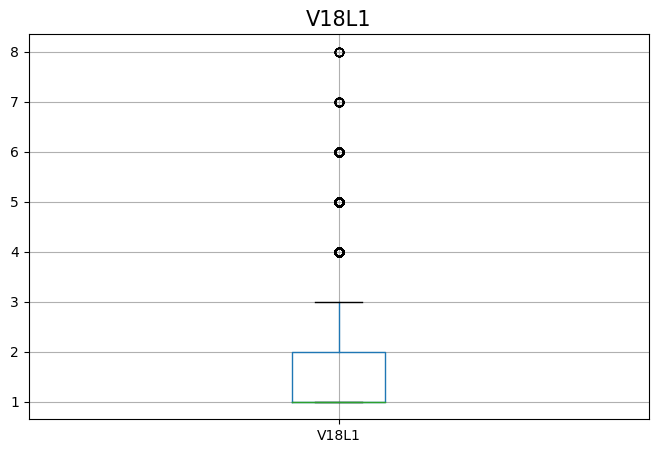

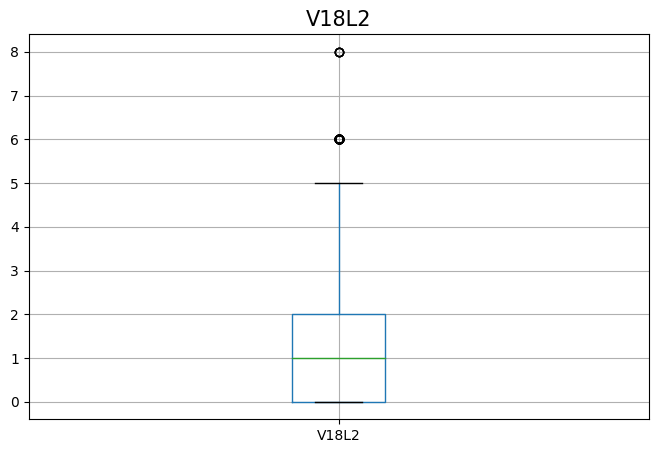

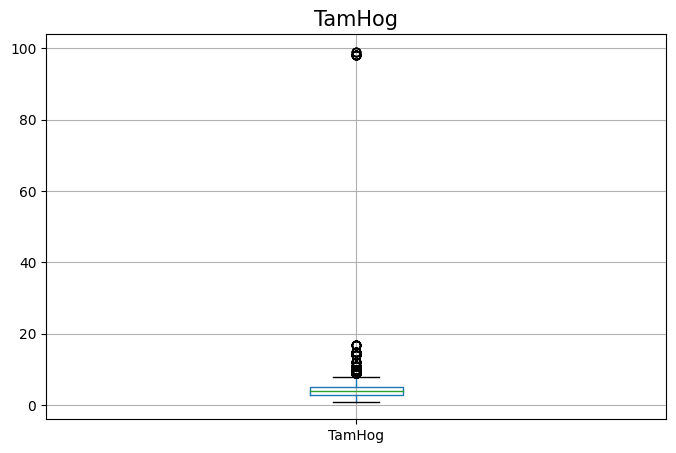

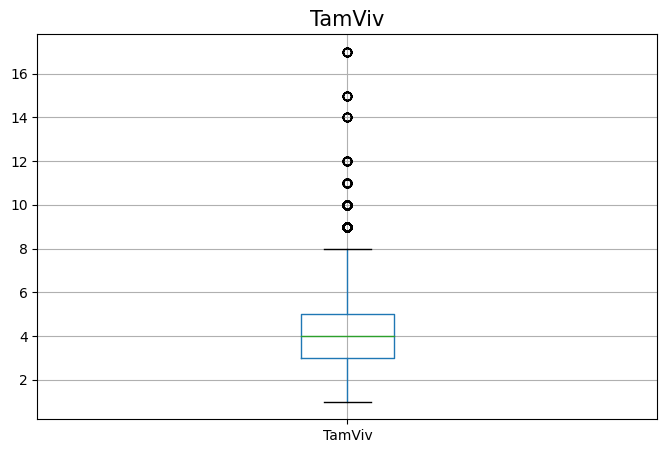

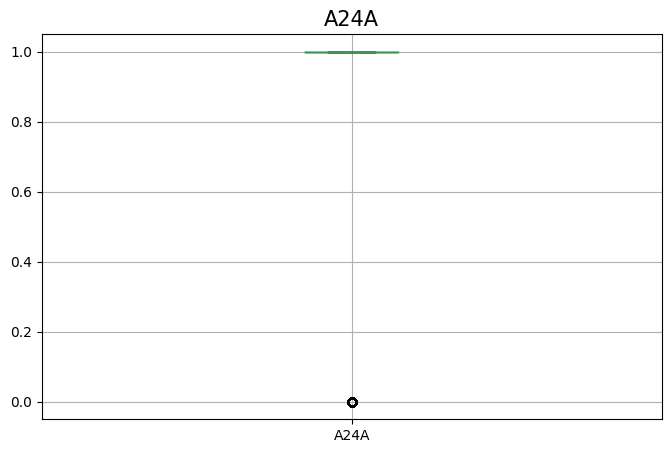

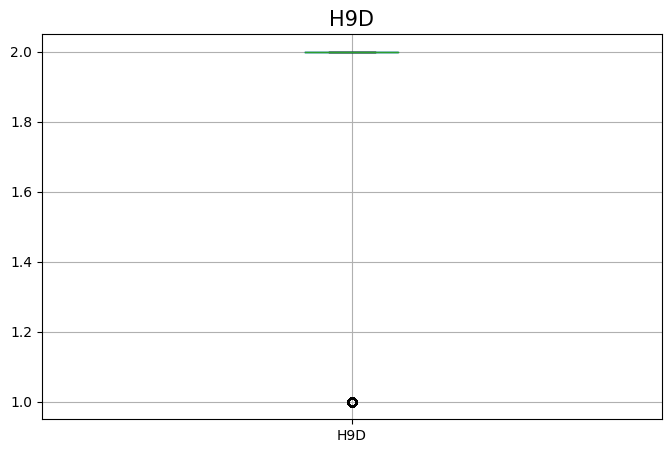

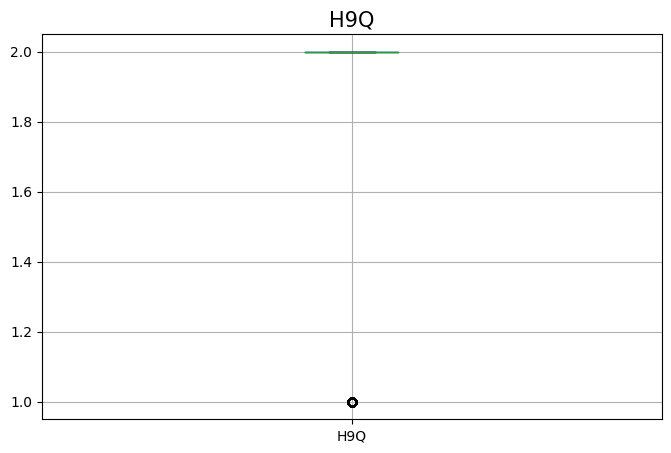

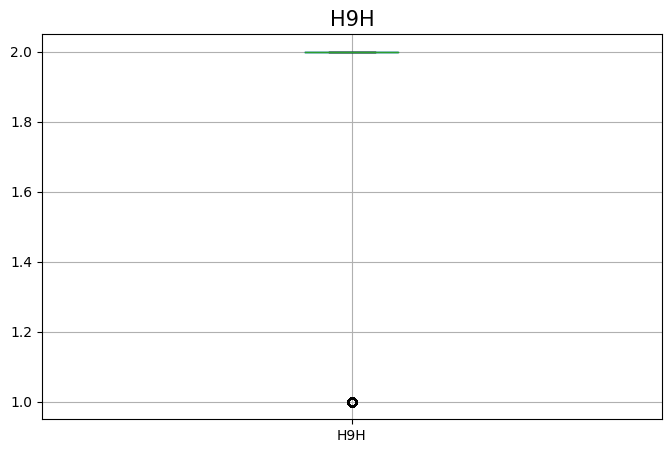

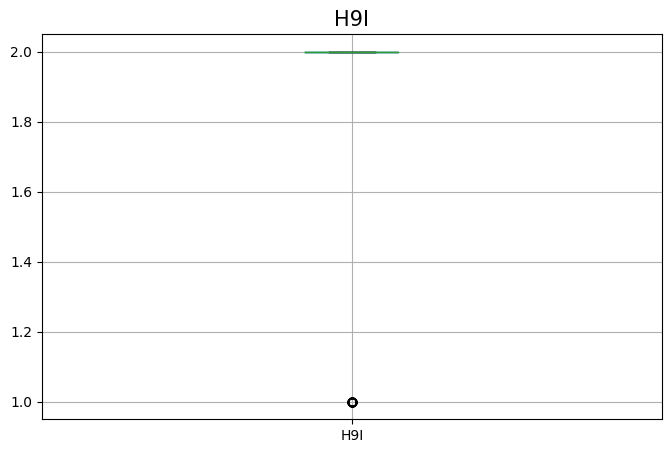

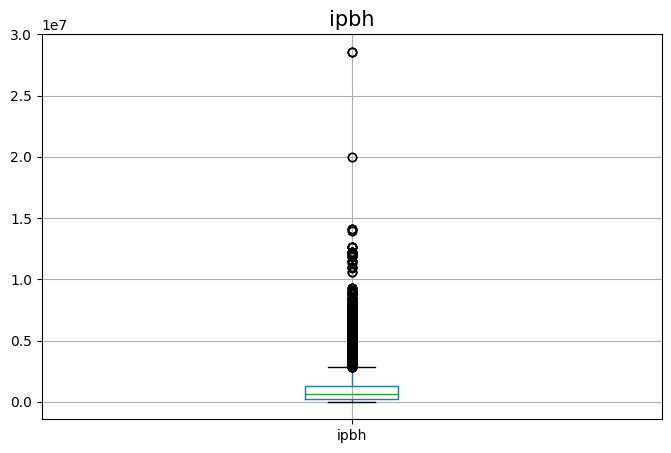

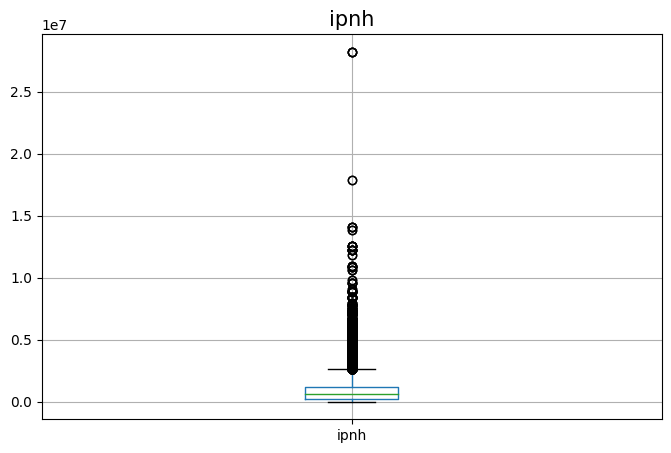

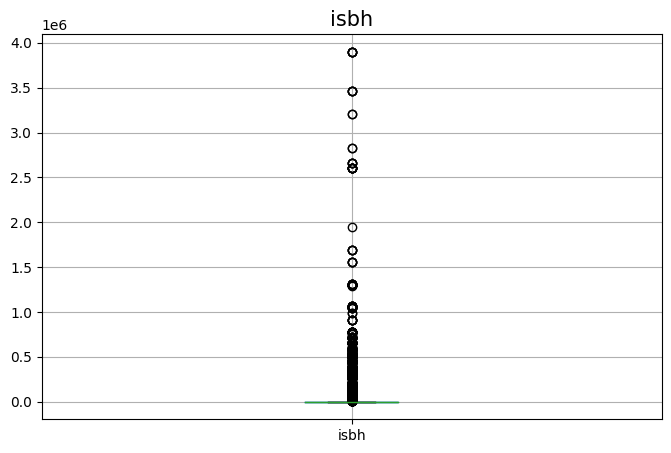

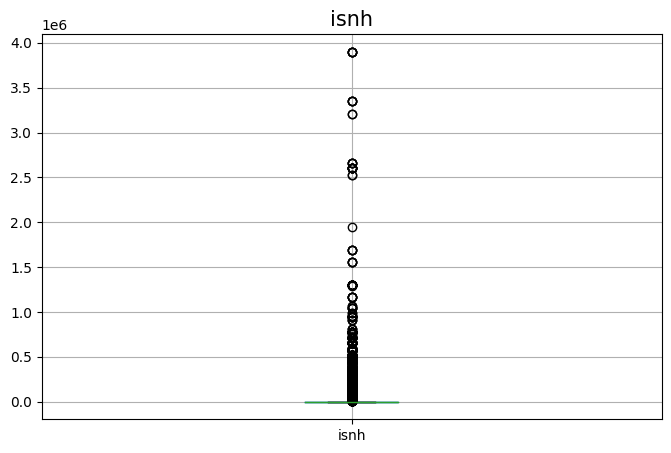

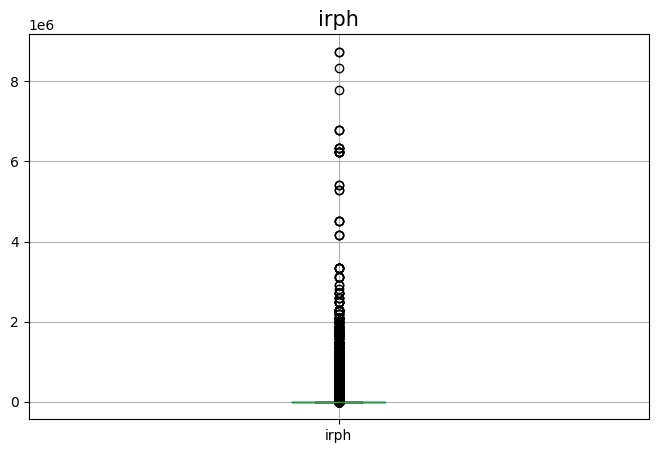

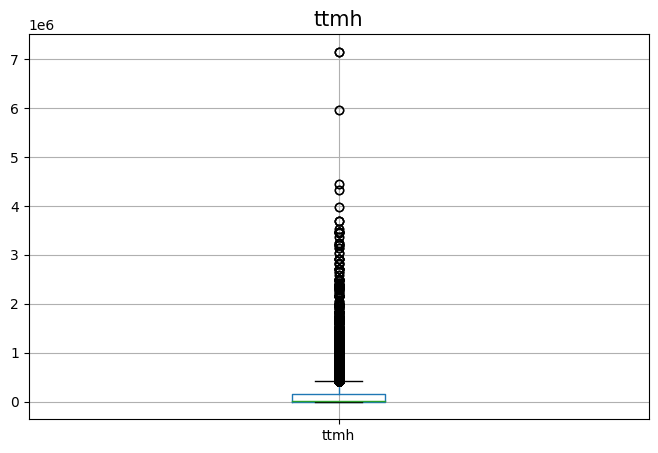

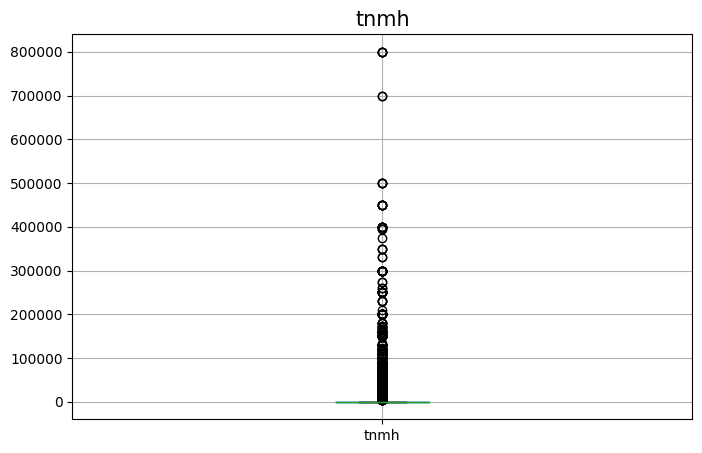

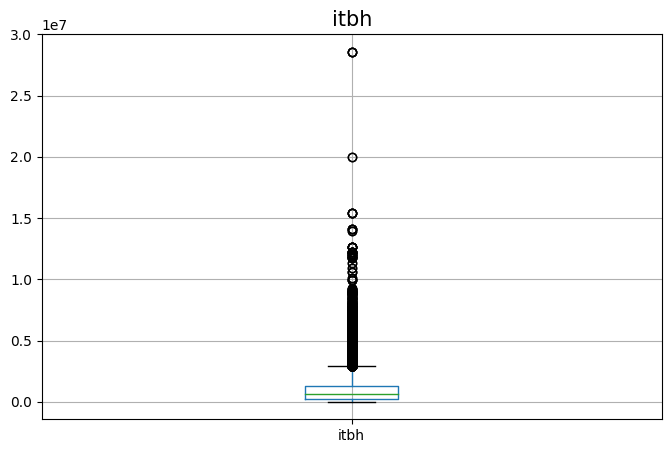

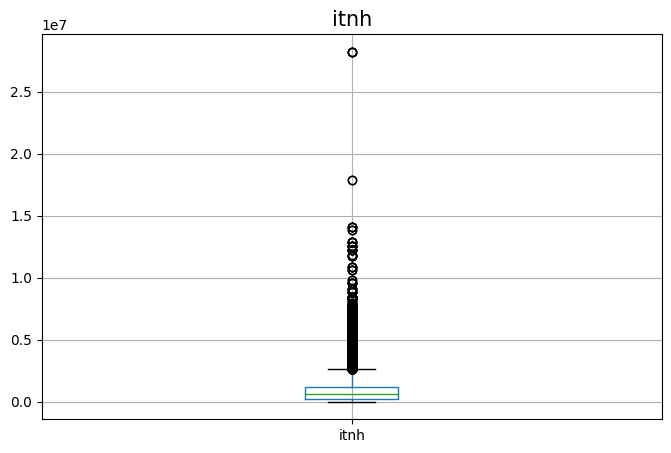

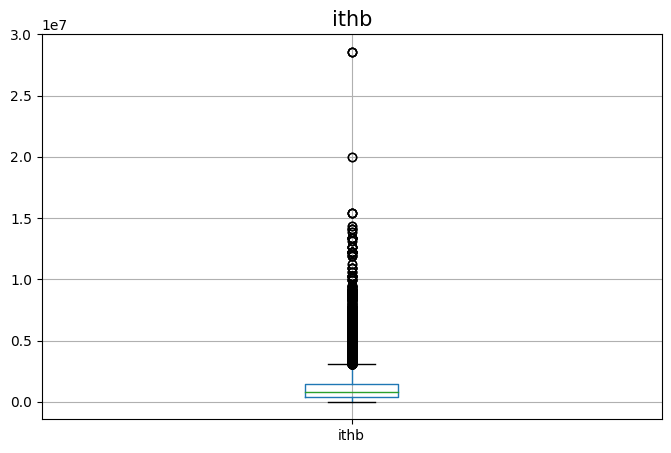

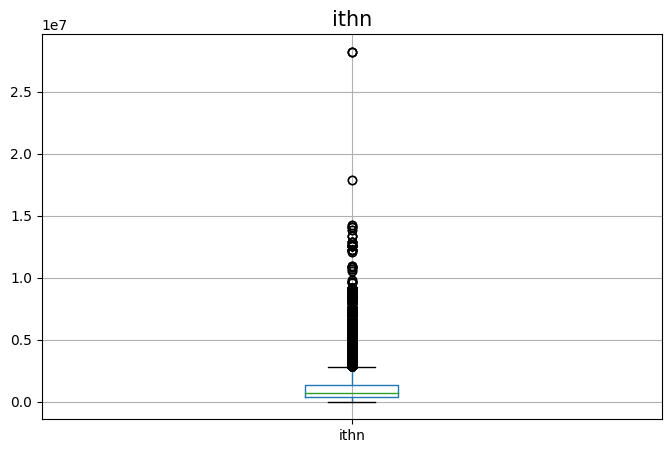

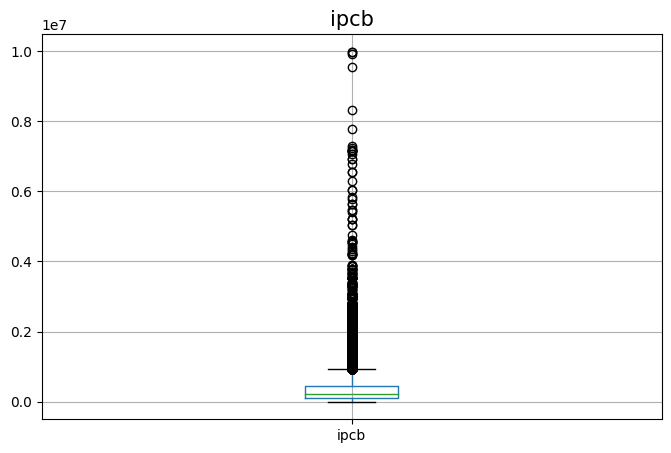

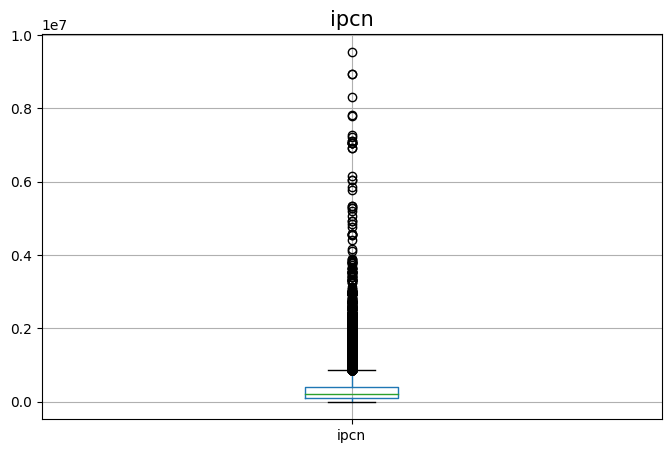

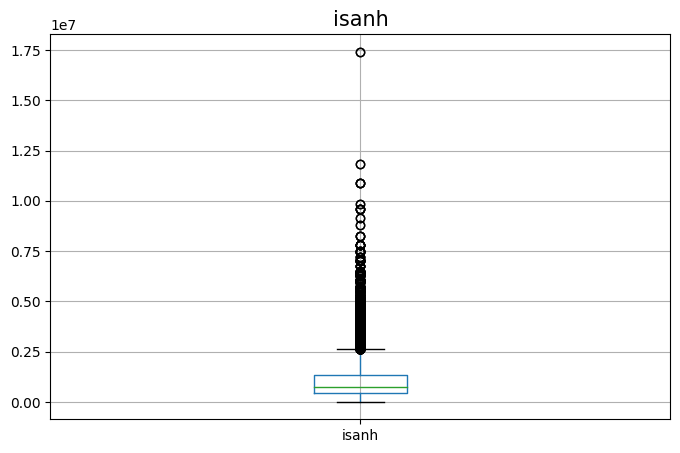

In [ ]:
#sns.set()
#genera el gráfico de cajas para las numéricas
for var in data2[var_num].columns.to_list():
    fig_dims = (8, 5)
    fig, ax = plt.subplots(figsize=fig_dims)
    data2.boxplot(column=[var])
    plt.title(var, size = 15)
    plt.show()

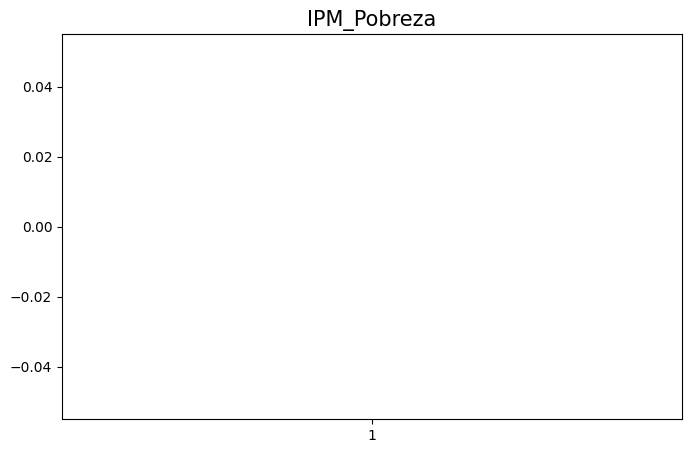

In [ ]:
fig_dims = (8, 5)
fig, ax = plt.subplots(figsize=fig_dims)

# para obtener los valores del gráfico(cap, whiskeys, fliers| outliers, maximun, minumun, quantiles)
# guarda en bp los elementos del gráfico
bp = plt.boxplot(data2['IPM_Pobreza'],showmeans=True)

#título del gráfico
plt.title('IPM_Pobreza', size = 15)

#muestra el gráfico
plt.show()

In [ ]:
#imprime las llaves del diccionario que contiene los elementos del gráfico
bp.keys()

dict_keys(['whiskers', 'caps', 'boxes', 'medians', 'fliers', 'means'])

![image.png](attachment:image.png)

In [ ]:
#imprime los valores del gráfico
for key, value in bp.items():
    print(key)
    print([item.get_ydata() for item in value])
    print()

whiskers
[array([nan, nan]), array([nan, nan])]

caps
[array([nan, nan]), array([nan, nan])]

boxes
[array([nan, nan, nan, nan, nan])]

medians
[array([nan, nan])]

fliers
[array([], dtype=float64)]

means
[array([nan])]



## Correlaciones entre las variables numéricas

In [ ]:
#genera la Matriz de Correlacion
round(data2[var_num].corr(),2)

,FACTOR,nro_Vivienda,HOGAR,LINEA,V2B,V8,V9,V14A1,V18A1,V18L1,V18L2,TamHog,TamViv,A24A,H9D,H9Q,H9H,H9I,ipbh,ipnh,isbh,isnh,irph,ttmh,tnmh,itbh,itnh,ithb,ithn,ipcb,ipcn,isanh
FACTOR,1.0,0.0,-0.0,-0.0,-0.0,0.1,0.1,0.1,0.1,0.1,0.1,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.1,0.1,-0.0,-0.0,0.0,0.1,-0.0,0.1,0.1,0.1,0.1,0.1,0.1,0.1
nro_Vivienda,0.0,1.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0
HOGAR,-0.0,0.0,1.0,-0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,-0.0,0.1,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
LINEA,-0.0,-0.0,-0.0,1.0,-0.0,0.2,0.1,0.0,0.4,0.1,0.1,0.3,0.6,-0.2,0.1,0.0,0.2,0.0,0.1,0.1,0.0,0.0,-0.0,-0.0,-0.0,0.1,0.1,0.1,0.1,-0.1,-0.1,0.0
V2B,-0.0,0.0,0.0,-0.0,1.0,0.0,0.0,0.1,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
V8,0.1,0.0,0.0,0.2,0.0,1.0,0.8,0.4,0.5,0.4,0.3,0.2,0.4,0.1,-0.0,0.0,-0.0,-0.0,0.3,0.3,0.0,0.0,0.1,0.2,-0.0,0.2,0.2,0.3,0.3,0.1,0.1,0.2
V9,0.1,0.0,0.0,0.1,0.0,0.8,1.0,0.5,0.4,0.4,0.3,0.1,0.2,0.1,-0.0,0.0,-0.1,-0.0,0.3,0.3,0.1,0.1,0.1,0.2,0.0,0.3,0.3,0.4,0.4,0.2,0.2,0.3
V14A1,0.1,0.0,0.0,0.0,0.1,0.4,0.5,1.0,0.2,0.4,0.3,0.1,0.0,0.1,-0.0,0.0,-0.1,-0.1,0.4,0.4,0.1,0.1,0.2,0.2,0.0,0.4,0.4,0.5,0.5,0.4,0.4,0.4
V18A1,0.1,0.0,0.1,0.4,-0.0,0.5,0.4,0.2,1.0,0.4,0.3,0.3,0.6,0.2,0.0,0.0,0.1,0.0,0.3,0.3,0.0,0.0,0.0,0.0,-0.1,0.3,0.3,0.3,0.3,0.0,0.0,0.2
V18L1,0.1,-0.0,0.0,0.1,0.0,0.4,0.4,0.4,0.4,1.0,0.7,0.1,0.1,0.1,-0.1,0.0,-0.0,-0.0,0.4,0.4,0.1,0.1,0.1,0.2,-0.0,0.4,0.4,0.5,0.5,0.3,0.3,0.4


Hacer una tabla donde coloques las variables que tengan correlacion significativa

## Mapa de calor de las Correlaciones

(32.5, -0.5)

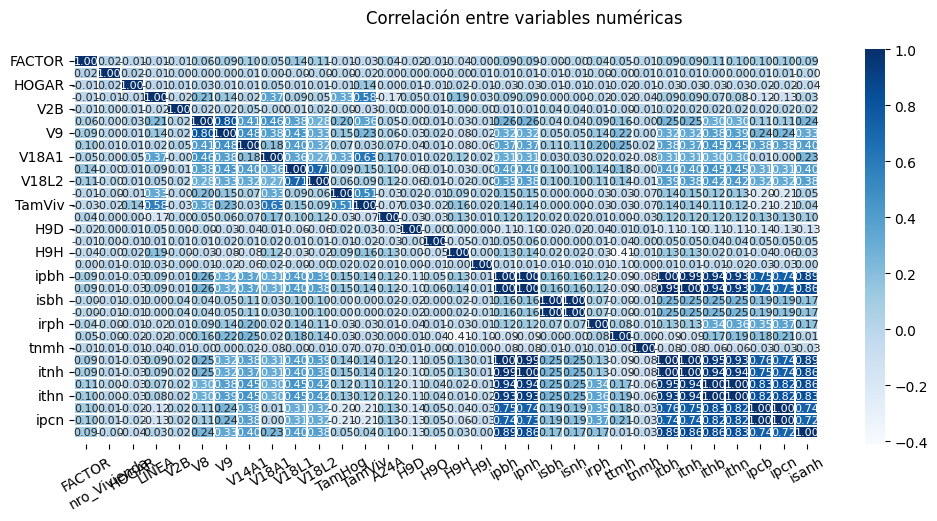

In [ ]:
#controla el ancho (valor izquierdo) y el alto (derecho) del gráfico
f, ax = plt.subplots(figsize=(12,5))

#genera la matriz de correlaciones
corr = data2[var_num].corr()

#gebera el mapa de calor, donde annot: coloca valores, cmap:color, fmt:formato de números
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap='Blues',fmt='.2f',linewidths=.1,annot_kws={'size': 8})

#controla la separación del título con el gráfico
f.subplots_adjust(top=0.9)

#título del gráfico
t= f.suptitle('Correlación entre variables numéricas', fontsize=12)

#controla la rotacion de las etiquetas en "x"
plt.xticks(rotation=30)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)

##Variables categóricas

In [ ]:
#imprime la cantidad de variables categóricas en la muestra
print('Número de variables categóricas: ', len(var_cat))

# visualiza las variables numéricas
data2[var_cat].head()

Número de variables categóricas:  145


,REGION,ZONA,V1,V2A,V3,V4,V5,V6,V6A,V7A,V7B,V7C,EFI,CalViv,HacDor,HacApo,V10,V11,V12,V13A,V13B,V14A,V14B,V15,V16,V17A,V17B1,V17B2,V17B3,V17B4,V17B5,V17B6,SerBa,V18A,V18B,V18C,V18D,V18E,V18F,V18G,V18Q,V18H,V18I,V18J,V18K,V18L,V18M,V22,V19,V19B1,V19B2,V19B3,V19B4,V19B8,V21,R4A,A3,A4,A5,A6,LugNac,CondMig,RegNac,RegResAnt,A8A,A8B,A9A,A10A,A10B,A10C,A11,A13,A14,A15A,NivInst,Escolari,A20A,A24B,A24C,A24D,A24E,A22A,B1,CondAct,H1A,H1C,H1E,H2A,H3A,H4A,H5A,H6A,H6B,H6C,H6D,H6E,H6F,TrabDomNoRem,ActPrimAutCon,OtroActAutCon,ActComVol,ActNoMer,H9A,H9B,H9C,H9E,H9P,H9F,H9G,H9R,H9S,H9T,H9K,H9L,H9M,cba,lp,np,IPM_E1,IPM_E2,IPM_E3,IPM_E4,IPM_VUI1,IPM_VUI2,IPM_VUI3,IPM_VUI4,IPM_S1,IPM_S2,IPM_S3,IPM_S4,IPM_T1,IPM_T2.1,IPM_T2.2,IPM_T3,IPM_PS1,IPM_PS2,IPM_PS3,IPM_PS4,IPM_Pobreza,Q_IPCN,D_IPCN,Q_ZON_IPCN,D_ZON_IPCN,Q_REG_IPCN,D_REG_IPCN
0,1,1,3,1,1,1,1,1,0,3,3,3,3,4,2,2,3,1,1,1,1.0,1,1.0,2,1,1,2,4,5,8,1,4,3,2,3,5,7,2,4,6,2,8,1,3,6,7,2,0,0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,2,80,5,1,1,1,1,0,0,0,0,0,0,8,0,16,1,2,6,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,4.0,8.0,4.0,7.0
1,1,1,3,1,1,1,1,1,0,3,3,3,3,4,2,2,3,1,1,1,1.0,1,1.0,2,1,1,2,4,5,8,1,4,3,2,3,5,7,2,4,6,2,8,1,3,6,7,2,0,0,NaN,NaN,NaN,NaN,NaN,0.0,1.0,9,2,84,5,1,1,1,1,0,0,0,0,0,0,8,0,16,1,2,6,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,4.0,8.0,4.0,7.0
2,1,1,3,1,2,1,1,1,0,2,2,2,2,3,2,2,3,1,1,1,1.0,1,1.0,2,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,2,51,2,2,2,7,1,0,0,0,0,0,0,14,0,16,4,2,6,1.0,0.0,0.0,0.0,5.0,0.0,2.0,3.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
3,1,1,3,1,2,1,1,1,0,2,2,2,2,3,2,2,3,1,1,1,1.0,1,1.0,2,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2,1,61,2,4,2,7,1,1,4,0,0,0,0,8,0,16,4,2,6,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0
4,1,1,3,1,2,1,1,1,0,2,2,2,2,3,2,2,3,1,1,1,1.0,1,1.0,2,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,1,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3,2,29,6,0,0,1,1,0,0,0,0,0,0,1,0,52,3,7,13,1.0,2.0,0.0,0.0,5.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,8.0,4.0,7.0,4.0,7.0


##Descripción de categóricas

In [ ]:
#genera tabla resumen de las categóricas
data2[var_cat].describe()

,REGION,ZONA,V1,V2A,V3,V4,V5,V6,V6A,V7A,V7B,V7C,EFI,CalViv,HacDor,HacApo,V10,V11,V12,V13A,V13B,V14A,V14B,V15,V16,V17A,V17B1,V17B2,V17B3,V17B4,V17B5,V17B6,SerBa,V18A,V18B,V18C,V18D,V18E,V18F,V18G,V18Q,V18H,V18I,V18J,V18K,V18L,V18M,V22,V19,V19B1,V19B2,V19B3,V19B4,V19B8,V21,R4A,A3,A4,A5,A6,LugNac,CondMig,RegNac,RegResAnt,A8A,A8B,A9A,A10A,A10B,A10C,A11,A13,A14,A15A,NivInst,Escolari,A20A,A24B,A24C,A24D,A24E,A22A,B1,CondAct,H1A,H1C,H1E,H2A,H3A,H4A,H5A,H6A,H6B,H6C,H6D,H6E,H6F,TrabDomNoRem,ActPrimAutCon,OtroActAutCon,ActComVol,ActNoMer,H9A,H9B,H9C,H9E,H9P,H9F,H9G,H9R,H9S,H9T,H9K,H9L,H9M,cba,lp,np,IPM_E1,IPM_E2,IPM_E3,IPM_E4,IPM_VUI1,IPM_VUI2,IPM_VUI3,IPM_VUI4,IPM_S1,IPM_S2,IPM_S3,IPM_S4,IPM_T1,IPM_T2.1,IPM_T2.2,IPM_T3,IPM_PS1,IPM_PS2,IPM_PS3,IPM_PS4,IPM_Pobreza,Q_IPCN,D_IPCN,Q_ZON_IPCN,D_ZON_IPCN,Q_REG_IPCN,D_REG_IPCN
count,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30512.0,30540,30445.0,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,25765.0,25765.0,25765.0,25765.0,25765.0,30514.0,30514.0,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,30540,27176.0,29126.0,29126.0,29126.0,29126.0,27176.0,26303.0,25002.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,25002.0,25002.0,25002.0,25002.0,25002.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,26303.0,30540,30540,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0,30514.0
unique,6,2,6,5,9,6,2,6,2,3,3,3,3,4,2,2,7,4,7,6,2.0,2,2.0,6,4,6,2,2,2,2,2,2,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,3.0,3.0,3.0,3.0,3.0,2.0,2.0,14,2,98,7,5,3,8,8,8,7,5,5,3,2,15,10,46,6,10,23,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,14.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0,10.0,5.0,10.0,5.0,10.0
top,1,1,2,1,1,1,1,1,0,3,3,3,3,4,2,2,3,1,1,2,1.0,1,1.0,1,2,1,2,4,6,8,2,4,3,1,4,5,8,2,4,6,2,8,2,4,6,7,2,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,2,15,6,0,0,1,1,0,0,0,0,0,0,5,0,16,1,2,6,0.0,0.0,0.0,0.0,5.0,0.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,4.0,6.0,8.0,2.0,4.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,62635,129038,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
freq,17438,21049,20167,20230,18414,29976,21113,23149,29507,16868,16629,17858,16849,16038,29701,30111,10759,29956,14911,22084,30385.0,30445,30368.0,15583,16309,27927,18450,15384,16374,16986,17256,30538,28615,29944,25482,29176,29054,27234,17598,26991,26800,30403,16775,17705,25420,26715,26541,18655,25765,25057.0,13971.0,16410.0,20566.0,25595.0,24611.0,17898.0,10630,16033,499,11228,20521,20521,15577,17139,27854,29876,28691,29990,30449,30533,8224,22123,6353,23928,6353,6353,22208.0,21269.0,27276.0,26952.0,24704.0,24126.0,14547.0,12343.0,20247.0,25899.0,21838.0,25448.0,26023.0,25858.0,25895.0,25395.0,25764.0,25364.0,25344.0,26055.0,26301.0,19397.0,24151.0,24287.0,24601.0,17790.0,25809.0,26198.0,26259.0,25186.0,25208.0,26247.0,25408.0,25894.0,23566.0,26283.0,26233.0,25309.0,26174.0,21049,21049,22725.0,29806.0,29680.0,28197.0,21531.0,26582.0,27864.0,27820.0,29535.0,22389.0,28829.0,30092.0,28457.0,29510.0,27166.0,21945.0,25768.0,29102.0,28820.0,27860.0,24999.0,25566.0,7172.0,3906.0,7387.0,3809.0,7194.0,3661.0


In [ ]:
data2['A10C'].value_counts()

,count
A10C,
0,30533
4,7


##Perfil resumido de variables categóricas

In [ ]:
#genera lista de variables que se usarán para obtener el perfil de muestra
lista_var = var_cat

#genera lista de categorias mas frecuentes de cada variable
lista_cat = []
for var in lista_var:
    lista_cat.append(statistics.mode(data[var].dropna()))

#genera lista de porcentajes maximos de categorias de cada variable
lista_porc = []
for var in lista_var:
    lista_porc.append(max(round(data[var].value_counts(normalize=True)*100,1)))

#crea lista de nombres que tendrá el DF final del perfil de la muestra
nombre_vars = ['Variable','Categoría más frecuente','Porcentaje']

#zipea todas las listas creadas anteriormente y crea tambien una lista de ellas
zipeo_listas = zip(lista_var,lista_cat,lista_porc)

#coloca las listas zipeadas y los nombres de las columnas en un DataFrame
perfil_muestra = pd.DataFrame(zipeo_listas, columns = nombre_vars)
#se ordena el DF segun los porcentajes (descendente) y se alinean los datos a la derecha.
perfil_muestra.sort_values(["Porcentaje"], ascending = False).style.set_properties(**{'text-align': 'left'})
#perfil_muestra.to_excel('Perfil_resumido_muestra.xlsx'

,Variable,Categoría más frecuente,Porcentaje
69,A10C,0.000000,100.000000
96,H6F,4.000000,100.000000
31,V17B6,4.000000,100.000000
111,H9T,2.000000,99.900000
104,H9C,2.000000,99.800000
107,H9F,2.000000,99.800000
21,V14A,1.000000,99.700000
22,V14B,1.000000,99.700000
68,A10B,0.000000,99.700000
112,H9K,2.000000,99.700000


In [ ]:
# lista_variables = []
# for i in data3.columns:
#     lista_variables.append(i)


# df_varible = pd.DataFrame(lista_variables, columns =['Variables'])
# df_varible.to_excel("df_variables_177.xlsx", index = False)

In [ ]:
data2['Q_REG_IPCN'].value_counts()

,count
Q_REG_IPCN,
1.0,7194
2.0,6538
3.0,6367
4.0,5636
5.0,4779


In [ ]:
data2.columns

Index(['FACTOR', 'nro_Vivienda', 'HOGAR', 'LINEA', 'REGION', 'ZONA', 'V1',
       'V2A', 'V2B', 'V3',
       ...
       'IPM_PS2', 'IPM_PS3', 'IPM_PS4', 'IPM_Pobreza', 'Q_IPCN', 'D_IPCN',
       'Q_ZON_IPCN', 'D_ZON_IPCN', 'Q_REG_IPCN', 'D_REG_IPCN'],
      dtype='object', length=177)

##FUNCION QUE GENERA LAS PRUEBAS CHI-CUADRADO

In [ ]:
######### FUNCION QUE GENERA LAS PRUEBAS CHI-CUADRADO ########
#round(1 - stats.chi2.cdf(1.06, 1),3)


def chi2_y_cramer(data2, nombre_variable, variable_id = None):
  """Esta funcion toma como 1er argumento un dataframe "df" que tiene solo variables categoricas, como segundo argumento el nombre de la variable
      etiqueta (debe estar entre comillas) y como 3er argumento el nombre del campo ID (entre comillas)
      para calcular los valores de CHI cuadrado y V de Cramer. Esta función devolve
      un dataframe con las columnas index= variables, chicuadrado, V de Cramer y la afirmacion
      existe relacion entre las variables y la etiqueta"""


  # este es una sintaxis para controlar los errores
  try:
    vars_categoricas = data2.select_dtypes('object')
  except:
    print("Problemas en la separacion de las categoricas")


  #Se crea el diccionario base vacio que se va a imprimir en un dataframe
  diccionario = {'variable': [], 'CHI2': [], 'V-Cramer' : [],'valor_p' : [], 'relacion' : []}

  #itera cada columna de la BD que contiene las variables categoricas
  for variable in vars_categoricas.columns:
    #Se excluye la variable codcli ya que es una columna ID
    if variable != variable_id:


      #Se crea una tabla de contingencia de cada variable categorica VS la Etiqueta, añadiendo los totales
      tabla_contingencia_total2 = pd.crosstab(index= vars_categoricas[variable], columns=vars_categoricas[nombre_variable], margins=True)

      #Se crea una tabla de contingencia de cada variable categorica VS la Etiqueta sin los totales
      tabla_contingencia2 = pd.crosstab(index=vars_categoricas[variable], columns=vars_categoricas[nombre_variable], margins=False)

      #Se realiza la prueba Chi-cuadrado con la tabla de contingencia con los totales
      resultados_chi22 = chi2_contingency(tabla_contingencia_total2)

      #Se guarda el valor del estadístico X2
      X2 = resultados_chi22[0]

      #se calculan los grados de libertad
      gl = (tabla_contingencia2.shape[0]-1)*(tabla_contingencia2.shape[1]-1)

      #Se obtiene el Valor-p de la prueba
      valor_p = round(1 - chi2.cdf(X2, gl),3)

      #Se guarda en "n" el total de individuos en la tabla de contigencia
      n = np.sum(np.array(tabla_contingencia2))

      #Se calcula parte del denominador del indicador V-Cramer (min(f,c) -1)
      minDim = min(tabla_contingencia2.shape) -1

      #Se calcula el indicador de asociación V-Cramer
      V = np.sqrt(X2 / (minDim * n))

      #crear la variable si existe relacion o no
      def define_si_relacion(valor):

        if valor > 0.01:
          return 'No'
        else:
          return 'Si'
      #Se agrega al diccionario vacio inicialmente creado la informacion de variables y elementos de la prueba Chi-cuadrado
      diccionario['variable'].append(variable)
      diccionario['CHI2'].append(round(resultados_chi22[0], 2))
      diccionario['V-Cramer'].append(round(V, 3))
      diccionario['valor_p'].append(round(valor_p, 3))
      diccionario['relacion'].append(define_si_relacion(valor_p))

  # Convertir el diccionario a un DF

  df = pd.DataFrame(diccionario)

  #Exporta to Excel y lo guarda en el directorio que este activo
  #df.to_excel('Tabla_chi2_categoricas.xlsx')
  return df

############ FUNCION QUE GENERA GRÁFICOS APILADOS 100% DE CATEGORICAS VS ETIQUETA ##############################################################



def grafica_categoricas_vs_etiqueta(df_tabla):
  df_tabla.plot(kind='bar', stacked=True, figsize=(15,8), )
  plt.legend(loc='best', bbox_to_anchor=(1.0, 0.5))
  plt.title(df_tabla.index.name  + ' VS '+ df_tabla.columns.name, fontsize=20)
  plt.show()


def crear_tabla_porcentaje_etiqueta(df, indice, columna, nombre_etiqueta):

  tabla = pd.pivot_table(data=df, values=indice, index = columna, columns=df[nombre_etiqueta], aggfunc='count')
  tabla['total'] = tabla['Developed'] + tabla['Developing']
  tabla['%_Developed'] = np.round(100 *tabla['Developed'] / tabla['total'],2)
  tabla['%_Developing'] = np.round(100 * tabla['Developing'] / tabla['total'],2)
  tabla.drop(['Developed','Developing','total'], axis=1, inplace=True)
  return tabla

######################################################## FUNCION QUE GENERA GRÁFICOS DE BARRAS DE LOS PROMEDIOS DE NUMERICAS VS ETIQUETA ##########################################################

def grafica_numerica_vs_etiqueta(df_numericas, df_target):
  """Esta funcion grafica el promedio de las variables numericas segun las categorias de la variable etiqueta.
  El argumento df_numericas representa un dataframe que contiene solo las variables numericas en estudio
  y df_target representa la variable independiente o etiqueta que se quiere predecir."""

  df_nuevo = pd.concat([df_numericas, df_target], axis=1)

  for columna in df_numericas.columns:
    sns.set()
    fit, ax = plt.subplots(figsize=(6, 6))
    sns.barplot(x=df_target, y=columna , data=df_nuevo, capsize=0.2, ax=ax, ci= None)

# show the mean
    for p in ax.patches:
      ax.annotate(f'mean:\n{p.get_height():0.2f}', (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.xlabel(df_target.name.replace('_',' '))
    plt.ylabel(columna.replace('_',' '))
    plt.title(columna.replace('_',' ').upper() + ' VS. ' + df_target.name.replace('_',' ').upper(),fontweight='bold')
    plt.show()
    print("\n"*5)


######################################################## FUNCION QUE GENERA TABLAS ANOVAS ENTRE NUMERICAS VS ETIQUETA ################################################

def crear_tablas_anovas(df_numericas, df_etiqueta):
  """Esta funcion genera la tabla de resultados de anovas entre las variables numericas y la etiqueta"""
  #Se concatena la BD de las numericas y la variable Etiqueta
  df_numericas_y_etiqueta = pd.concat([df_numericas,df_etiqueta], axis=1)


  #Crea la plantilla del DataFrame
  diccionario = {'variable': [],'F' : [], 'valor_p' : []}

  for variable in df_numericas_y_etiqueta.columns:

    if variable != df_etiqueta.name:
      #Crea el modelo ANOVA
      concatenar_variable_etiqueta = str(df_numericas_y_etiqueta[variable].name+ ' ~ ' + df_etiqueta.name)
      mod = ols(concatenar_variable_etiqueta, data = df_numericas_y_etiqueta).fit()

      #Crea tabla con los resultados del ANOVA
      aov_table = sm.stats.anova_lm(mod, type=2)

      diccionario['variable'].append(variable)
      diccionario['F'].append(round(aov_table.F[0],3))
      diccionario['valor_p'].append(round(aov_table['PR(>F)'][0],3))
      # print(concatenar_variable_etiqueta)
      # print(aov_table.loc['Residual','sum_sq'])
      #aov_table
  df_anova = pd.DataFrame(diccionario)
  return df_anova

In [ ]:
diccionario = chi2_y_cramer(data2[lista_cardinalidad], "etiqueta_1C", variable_id = "IPM_Pobreza")
diccionario

NameError: name 'lista_cardinalidad' is not defined

In [ ]:
tabla_chi_def = diccionario[diccionario['relacion'] == 'Si']
#tabla_chi_def
tabla_chi_def.sort_values(by=['CHI2'], ascending=False)

NameError: name 'diccionario' is not defined

In [ ]:
list_selected = []
for i in tabla_chi_def['variable']:
    list_selected.append(i)
list_selected.append('codcli')
list_selected

In [ ]:
# Recorre cada variable categorica en la BD "df_categoricas"
for i in data[list_selected].columns.to_list():
  if  i != 'codcli':
    #Crea tablas de contingencia (categoricas VS Etiqueta) con la función "crear_tabla_porcentaje_etiqueta()"
    tabla = crear_tabla_porcentaje_etiqueta(data[list_selected], 'codcli', i, 'etiqueta_1C')

    #Grafica las variables categoricas VS Etiqueta segun la función  "grafica_categoricas_vs_etiqueta()"
    grafica_categoricas_vs_etiqueta(tabla)

    #Para dejar un espacio de 5 lineas entre cada gráfico
    print("\n" *5)

In [ ]:
grafica_numerica_vs_etiqueta(data[var_num], data.Status)

In [ ]:
var_num_provis = ['Alcohol',
 'Polio',
 'GDP',
 'Population',
 'Schooling']

In [ ]:
var_num_provis

In [ ]:
df_anova = crear_tablas_anovas(data[var_num_provis], data.Status)
df_anova

In [ ]:
# #se concatenaron la tabla de la prueba chi-cuadrado y ANOVA usando pd.concat y se ignoran los indices.
# df_concat_anova_Ch2 = pd.concat([df_anova[['variable','valor_p']],diccionario[['variable','valor_p']]], ignore_index=True)

# #Se filtran las variables cuyo valor-p sea menor a 0.05 almacenandolos en una lista
# variables_seleccionadas = df_concat_anova_Ch2[df_concat_anova_Ch2['valor_p'] < 0.01]
# variables_seleccionadas.variable.to_list()

# #crea lista de variables seleccionadas
# lista_variables_seleccionadas = variables_seleccionadas.variable.to_list() + ['codcli']

# #Se arma un data frame con las variables seleccionadas a partir del data frame "df_simplificado1"
# df_variables_seleccionadas = data[lista_variables_seleccionadas]
# df_variables_seleccionadas